In [ ]:
pip install torchmetrics


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install torchmetrics
!pip install brian2


In [ ]:
import torchmetrics
import Brian2
print(torchmetrics.__version__)
print(Brian2.__version__)

In [ ]:
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch, librosa
# load clean and denoised signals
clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
denoised, _ = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

# convert to tensors
clean_t = torch.tensor(clean)
denoised_t = torch.tensor(denoised)

metric = ScaleInvariantSignalNoiseRatio()
si_snr_value = metric(denoised_t, clean_t)
print("SI-SNR:", si_snr_value.item(), "dB")


In [ ]:
import librosa, librosa.display, numpy as np, soundfile as sf

# Load noisy audio
noisy, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

# Compute STFT
stft_noisy = librosa.stft(noisy, n_fft=1024, hop_length=256)
magnitude, phase = np.abs(stft_noisy), np.angle(stft_noisy)

# Estimate noise profile from first 0.5 s
noise_profile = np.mean(magnitude[:, :int(0.5*sr/256)], axis=1, keepdims=True)

# Apply simple spectral gating
gate_threshold = 1.2
clean_mag = np.maximum(magnitude - gate_threshold * noise_profile, 0)

# Reconstruct signal
stft_denoised = clean_mag * np.exp(1j * phase)
denoised = librosa.istft(stft_denoised, hop_length=256)

# Save
sf.write("stft_denoised.wav", denoised, sr)
print("Saved: stft_denoised.wav")


In [ ]:
min_len = min(len(clean), len(denoised))
clean_t = torch.tensor(clean[:min_len])
denoised_t = torch.tensor(denoised[:min_len])

si_snr_value = metric(denoised_t, clean_t)
print("Baseline STFT SI-SNR:", si_snr_value.item(), "dB")


In [ ]:
pip install Brian2 soundfile librosa torchmetrics


In [ ]:
import numpy as np, librosa, soundfile as sf
from brian2 import *

# load noisy and clean signals
clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

# downsample slightly to keep Brian2 fast
sr_new = 4000
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(noisy, orig_sr=sr, target_sr=sr_new)

duration = len(noisy) / sr_new * second
num_inputs = 200  # compress time dimension for faster sim
indices = np.linspace(0, len(noisy)-1, num_inputs).astype(int)
rates = np.abs(noisy[indices]) * 200*Hz + 1*Hz


In [ ]:
start_scope()

# Input layer
input_layer = PoissonGroup(num_inputs, rates=rates)

# Hidden (cortical column)
hidden_layer = NeuronGroup(100, '''
dv/dt = -v / (10*ms) : 1
''', threshold='v>1', reset='v=0', method='exact')

# Output (reconstruction)
output_layer = NeuronGroup(num_inputs, '''
dv/dt = -v / (10*ms) : 1
''', threshold='v>1', reset='v=0', method='exact')

# Synapses
S_in = Synapses(input_layer, hidden_layer, 'w : 1', on_pre='v_post += w')
S_hid = Synapses(hidden_layer, output_layer, 'w : 1', on_pre='v_post += w')
S_in.connect(p=0.5)
S_hid.connect(p=0.5)
S_in.w = '0.2*rand()'
S_hid.w = '0.2*rand()'

# Monitors
M_out = SpikeMonitor(output_layer)
run(duration)
print("Simulation done.")


In [ ]:
spike_counts = np.zeros(num_inputs)
for i in M_out.i:
    spike_counts[i] += 1

decoded = spike_counts / np.max(spike_counts)
# interpolate back to original length
decoded_full = np.interp(np.arange(len(noisy)), np.linspace(0, len(noisy)-1, num_inputs), decoded)
sf.write("sacc_output.wav", decoded_full, sr_new)
print("Saved denoised output.")


In [ ]:
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch

metric = ScaleInvariantSignalNoiseRatio()
clean_t = torch.tensor(clean)
denoised_t = torch.tensor(decoded_full)
si_snr_value = metric(denoised_t, clean_t)
print("SACC prototype SI-SNR:", si_snr_value.item(), "dB")


In [ ]:
from brian2 import *
import numpy as np, soundfile as sf
from scipy.ndimage import gaussian_filter1d

# Reuse 'noisy', 'clean', sr_new, duration, num_inputs, rates' from earlier
start_scope()

# ---------- Network ----------
input_layer = PoissonGroup(num_inputs, rates=rates)
hidden_layer = NeuronGroup(100, 'dv/dt = -v/(10*ms) : 1',
                           threshold='v>1', reset='v=0', method='exact')
output_layer = NeuronGroup(num_inputs, 'dv/dt = -v/(10*ms) : 1',
                           threshold='v>1', reset='v=0', method='exact')

S_in = Synapses(input_layer, hidden_layer, 'w : 1', on_pre='v_post += w')
S_hid = Synapses(hidden_layer, output_layer, 'w : 1', on_pre='v_post += w')
S_in.connect(p=0.4)
S_hid.connect(p=0.4)

# Weight scaling based on noisy amplitude pattern
amp_pattern = np.abs(noisy[::max(1, len(noisy)//num_inputs)])[:num_inputs]
amp_pattern = amp_pattern / (np.max(amp_pattern) + 1e-8)
# assign scaled weights directly to postsynaptic index
S_in.w = 0.4 * amp_pattern[S_in.j % num_inputs]
S_hid.w = '0.2 + 0.1*rand()'

M_out = SpikeMonitor(output_layer)
run(duration)
print("Simulation done.")

# ---------- Decode spikes ----------
spike_counts = np.zeros(num_inputs)
for i in M_out.i:
    spike_counts[i] += 1

decoded = gaussian_filter1d(spike_counts, sigma=2)
decoded = decoded / (np.max(decoded) + 1e-8)
decoded_full = np.interp(np.arange(len(noisy)),
                         np.linspace(0, len(noisy)-1, num_inputs),
                         decoded)
sf.write("sacc_output_fixed.wav", decoded_full, sr_new)
print("Saved: sacc_output_fixed.wav")


In [ ]:
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch

metric = ScaleInvariantSignalNoiseRatio()
clean_t = torch.tensor(clean)
denoised_t = torch.tensor(decoded_full)
si_snr_value = metric(denoised_t, clean_t)
print("SACC (weighted + smoothed) SI-SNR:", si_snr_value.item(), "dB")


In [ ]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from brian2 import *

# Load audio files (you can replace with your own samples)
clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

# Downsample for faster simulation
sr_new = 4000
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(noisy, orig_sr=sr, target_sr=sr_new)

# Reduce length (first 0.5 s only, enough for learning)
segment_dur = 0.5  # seconds
segment_len = int(sr_new * segment_dur)
clean = clean[:segment_len]
noisy = noisy[:segment_len]

# Convert amplitude to firing rates (0–200 Hz)
num_inputs = 200
indices = np.linspace(0, len(noisy) - 1, num_inputs).astype(int)
signal_segment = noisy[indices]
rates = (np.abs(signal_segment) / np.max(np.abs(signal_segment))) * 200 * Hz

# Quick visualization
plt.figure(figsize=(10,3))
plt.plot(signal_segment)
plt.title("Noisy Audio Segment (used for spike encoding)")
plt.show()

print(f"Sample rate: {sr_new} Hz, duration: {segment_dur} s, inputs: {num_inputs}")
print("Example firing rates (Hz):", rates[:10])


In [ ]:
# =========================================================
#  Spiking Autoencoder Cortex Circuit (SACC) - Reward-STDP Version
#  Experimental simulation for IEEE EIT 2026
# =========================================================

# ---------- 1. Setup ----------
!pip install brian2 torchmetrics librosa soundfile -q

import numpy as np
import librosa, soundfile as sf
import matplotlib.pyplot as plt
from brian2 import *
from scipy.ndimage import gaussian_filter1d
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch

print("Setup complete ✅")

# ---------- 2. Load and encode audio ----------
print("\nLoading and encoding audio...")

clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

# Downsample for faster simulation
sr_new = 4000
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(noisy, orig_sr=sr, target_sr=sr_new)

# Use first 1.0 s segment
segment_dur = 1.0
segment_len = int(sr_new * segment_dur)
clean = clean[:segment_len]
noisy = noisy[:segment_len]

# Spike encoding (rate code)
num_inputs = 200
indices = np.linspace(0, len(noisy)-1, num_inputs).astype(int)
signal_segment = noisy[indices]
rates = (np.abs(signal_segment) / np.max(np.abs(signal_segment))) * 200 * Hz

plt.figure(figsize=(10,3))
plt.plot(signal_segment)
plt.title("Noisy Audio Segment (used for spike encoding)")
plt.show()
print(f"Sample rate: {sr_new} Hz | Duration: {segment_dur}s | Encoded inputs: {num_inputs}")
print("Encoding complete ✅")

# ---------- 3. SACC STDP Network ----------
print("\nInitializing SACC network...")

num_outputs = num_inputs
duration = segment_dur * second
eta = 0.02  # stable learning rate

start_scope()

# Input Poisson spike generator
input_layer = PoissonGroup(num_inputs, rates=rates)

# Output neurons with bias current (keep spiking)
output_layer = NeuronGroup(num_outputs,
    '''
    dv/dt = (-v + 0.1)/(10*ms) : 1
    ''',
    threshold='v>0.5', reset='v=0', method='exact')

# Normalized clean audio as time-varying reward
clean_norm = (clean - np.min(clean)) / (np.max(clean) - np.min(clean))
reward_signal = TimedArray(clean_norm, dt=1*ms)

# Reward-modulated STDP synapses
# ---------- Reward-modulated STDP synapses ----------
# ---------- Reward-modulated STDP synapses ----------
# ---------- Reward-modulated STDP synapses (fixed, clean syntax) ----------
S = Synapses(input_layer, output_layer,
    '''
    w : 1
    dpre/dt = -pre/(20*ms) : 1 (event-driven)
    dpost/dt = -post/(20*ms) : 1 (event-driven)
    reward = reward_signal(t) : 1 (shared)
    ''',
    on_pre='''
    v_post += 0.6*w
    pre += 1.
    w = clip(w + 0.01*post - 0.001*w, 0, 1)
    ''',
  on_post='''
    post += 1.
    v_post -= 0.05*post
    w = clip(w + 0.02*pre + 0.005*reward - 0.0005*w, 0, 1)
    '''
)
S.connect(p=0.1)
S.w = '0.4 + 0.1*rand()'



M_out = SpikeMonitor(output_layer)
M_w = StateMonitor(S, 'w', record=range(5))

print("Running STDP simulation (1 s)...")
run(duration)
print("STDP simulation completed ✅")

# ---------- 4. Visualization ----------
plt.figure(figsize=(10,4))
plt.plot(M_out.t/ms, M_out.i, '.k', markersize=1)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Output spike raster after Reward-STDP learning')
plt.show()

plt.figure(figsize=(10,3))
for i in range(5):
    plt.plot(M_w.t/ms, M_w.w[i], label=f'w{i}')
plt.xlabel('Time (ms)')
plt.ylabel('Weight value')
plt.title('Evolution of first 5 synaptic weights')
plt.legend()
plt.show()
print("Visualization done ✅")

# ---------- 5. Decode & Evaluate ----------
print("\nDecoding and evaluating results...")

spike_counts = np.zeros(num_outputs)
for i in M_out.i:
    spike_counts[i] += 1

decoded = gaussian_filter1d(spike_counts, sigma=2)
decoded = decoded / (np.max(decoded) + 1e-8)
decoded_full = np.interp(np.arange(len(noisy)),
                         np.linspace(0, len(noisy)-1, num_outputs),
                         decoded)

sf.write("sacc_stdp_output.wav", decoded_full, sr_new)
print("Saved: sacc_stdp_output.wav")

metric = ScaleInvariantSignalNoiseRatio()
clean_t = torch.tensor(clean)
denoised_t = torch.tensor(decoded_full[:len(clean)])
si_snr_value = metric(denoised_t, clean_t)
print(f"SACC (Reward-STDP) SI-SNR: {si_snr_value.item():.2f} dB")

energy_proxy = np.sum(spike_counts)
print(f"Total spikes (energy proxy): {energy_proxy:.0f}")
print("Evaluation complete ✅")

# =========================================================
#  End of SACC Notebook - Baseline experimental result
# =========================================================


In [ ]:
# =========================================================
#  Spiking Autoencoder Cortex Circuit (SACC) - Minimal Prototype
#  Reward-modulated STDP Learning (Simplified) 02/11/2026
#  Version: Initial Experimental Implementation for IEEE EIT 2026
# =========================================================

# ---------- 1. Setup ----------
!pip install brian2 librosa soundfile torchmetrics -q

import numpy as np
import matplotlib.pyplot as plt
from brian2 import *
import librosa, soundfile as sf
from scipy.ndimage import gaussian_filter1d
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch

print("Environment ready ✅")

# ---------- 2. Load & Preprocess Audio ----------
print("\nLoading audio segment...")

# Paths from Valentini dataset
clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

# Downsample for faster simulation
sr_new = 4000
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(noisy, orig_sr=sr, target_sr=sr_new)

# Take 0.5s segment
segment_dur = 0.5
segment_len = int(sr_new * segment_dur)
clean = clean[:segment_len]
noisy = noisy[:segment_len]

# Normalize
clean /= np.max(np.abs(clean)) + 1e-9
noisy /= np.max(np.abs(noisy)) + 1e-9

print(f"Segment length: {segment_len} samples, duration: {segment_dur}s, sr={sr_new}")

# ---------- 3. Spike Encoding ----------
num_inputs = 100
indices = np.linspace(0, len(noisy)-1, num_inputs).astype(int)
signal_segment = noisy[indices]

# Map amplitude to spike rate (0–200 Hz)
rates = (np.abs(signal_segment) / np.max(np.abs(signal_segment))) * 200 * Hz

plt.figure(figsize=(8,3))
plt.plot(signal_segment)
plt.title("Noisy Audio Segment for Spike Encoding")
plt.xlabel("Sample index"); plt.ylabel("Amplitude")
plt.show()

# ---------- 4. Reward Signal ----------
reward_raw = np.abs(clean)
reward_smoothed = gaussian_filter1d(reward_raw, sigma=5)
reward_signal = TimedArray(reward_smoothed, dt=(1/sr_new)*second)
print("Reward signal created (smoothed amplitude envelope).")

plt.figure(figsize=(8,3))
plt.plot(reward_smoothed)
plt.title("Reward Signal (Smoothed Clean Amplitude)")
plt.xlabel("Sample index"); plt.ylabel("Reward Value")
plt.show()

# ---------- 5. SACC Network (Simplified) ----------
print("\nBuilding SACC network...")

start_scope()

num_outputs = num_inputs
duration = segment_dur * second
eta = 0.02   # learning rate

input_layer = PoissonGroup(num_inputs, rates=rates)
output_layer = NeuronGroup(num_outputs,
    '''
    dv/dt = -v/(20*ms) : 1
    ''',
    threshold='v>1', reset='v=0', method='exact')

# Reward-modulated STDP synapses
S = Synapses(input_layer, output_layer,
    '''
    w : 1
    dpre/dt  = -pre/(20*ms)  : 1 (event-driven)
    dpost/dt = -post/(20*ms) : 1 (event-driven)
    ''',
    on_pre='''
    v_post += w
    pre += 1.
    w = clip(w - 0.002*w, 0, 1)
    ''',
    on_post='''
    post += 1.
    w = clip(w + eta*(reward_signal(t)-0.3)*pre, 0, 1)
    ''')
S.connect(p=0.3)
S.w = '0.5*rand()'

M_out = SpikeMonitor(output_layer)
M_w = StateMonitor(S, 'w', record=range(5))

print("Network initialized successfully ✅")

# ---------- 6. Run Simulation ----------
print("\nRunning simulation...")
run(duration)
print("Simulation complete ✅")

# ---------- 7. Visualization ----------
plt.figure(figsize=(10,4))
plt.plot(M_out.t/ms, M_out.i, '.k', markersize=1)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Output Spike Raster (SACC Reward-STDP)')
plt.show()

plt.figure(figsize=(10,3))
for i in range(5):
    plt.plot(M_w.t/ms, M_w.w[i], label=f'w{i}')
plt.xlabel('Time (ms)')
plt.ylabel('Weight value')
plt.title('Evolution of First 5 Synaptic Weights')
plt.legend()
plt.show()

# ---------- 8. Decode & Evaluate ----------
spike_counts = np.zeros(num_outputs)
for i in M_out.i:
    spike_counts[i] += 1

decoded = gaussian_filter1d(spike_counts, sigma=2)
decoded /= np.max(decoded) + 1e-8
decoded_full = np.interp(np.arange(len(noisy)),
                         np.linspace(0, len(noisy)-1, num_outputs),
                         decoded)

sf.write("sacc_minimal_output.wav", decoded_full, sr_new)
print("Saved: sacc_minimal_output.wav")

# SI-SNR (for quick check)
metric = ScaleInvariantSignalNoiseRatio()
clean_t = torch.tensor(clean)
denoised_t = torch.tensor(decoded_full[:len(clean)])
si_snr_value = metric(denoised_t, clean_t)
print("SACC (minimal) SI-SNR:", si_snr_value.item(), "dB")

energy_proxy = np.sum(spike_counts)
print("Total spikes (energy proxy):", energy_proxy)


In [ ]:
# =========================================================
#  Spiking Autoencoder Cortex Circuit (SACC) 02/11/2026
#  Reward-Modulated STDP with Global Inhibition version2(v2)
# =========================================================

!pip install brian2 librosa soundfile torchmetrics -q

import numpy as np
import matplotlib.pyplot as plt
from brian2 import *
import librosa, soundfile as sf
from scipy.ndimage import gaussian_filter1d
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch

print("Setup complete ✅")

# ---------- 1. Load & Prepare Audio ----------
clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

sr_new = 4000
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(noisy, orig_sr=sr, target_sr=sr_new)

segment_dur = 0.5
segment_len = int(sr_new * segment_dur)
clean = clean[:segment_len]
noisy = noisy[:segment_len]
clean /= np.max(np.abs(clean)) + 1e-9
noisy /= np.max(np.abs(noisy)) + 1e-9

print(f"Loaded 0.5s segment at {sr_new} Hz.")

# ---------- 2. Spike Encoding ----------
num_inputs = 100
indices = np.linspace(0, len(noisy)-1, num_inputs).astype(int)
signal_segment = noisy[indices]
rates = (np.abs(signal_segment) / np.max(np.abs(signal_segment))) * 200 * Hz

plt.figure(figsize=(8,3))
plt.plot(signal_segment)
plt.title("Input Noisy Segment")
plt.show()

# ---------- 3. Reward Signal ----------
reward_raw = np.abs(clean)
reward_smoothed = gaussian_filter1d(reward_raw, sigma=10)
reward_smoothed = (reward_smoothed - np.min(reward_smoothed)) / (np.max(reward_smoothed) + 1e-9)
reward_signal = TimedArray(reward_smoothed, dt=(1/sr_new)*second)

plt.figure(figsize=(8,3))
plt.plot(reward_smoothed)
plt.title("Normalized Reward Signal (σ=10)")
plt.show()

# ---------- 4. SACC Network ----------
print("Building network...")

start_scope()

num_outputs = num_inputs
duration = segment_dur * second
eta = 0.05  # stronger reward coupling

input_layer = PoissonGroup(num_inputs, rates=rates)
output_layer = NeuronGroup(num_outputs,
    '''
    dv/dt = -v/(20*ms) : 1
    bias : 1
    ''',
    threshold='v > 1 + bias',
    reset='v = 0',
    method='exact')

output_layer.v = 0
output_layer.bias = 0.0

# Reward-modulated STDP
S = Synapses(input_layer, output_layer,
    '''
    w : 1
    dpre/dt  = -pre/(20*ms)  : 1 (event-driven)
    dpost/dt = -post/(20*ms) : 1 (event-driven)
    ''',
    on_pre='''
    v_post += w
    pre += 1.
    w = clip(w - 0.001*w, 0, 1)
    ''',
    on_post='''
    post += 1.
    w = clip(w + eta*(reward_signal(t)-0.3)*pre, 0, 1)
    ''')
S.connect(p=0.3)
S.w = '0.5*rand()'

# ---------- 5. Global Inhibition ----------
spike_counter = 0

@network_operation(dt=10*ms)
def global_inhibition():
    global spike_counter
    recent_spikes = len(M_out.t[(M_out.t > defaultclock.t - 10*ms)])
    target_spikes = num_outputs * 0.05  # keep ~5% active
    adj = (recent_spikes - target_spikes) / (target_spikes + 1e-6)
    output_layer.bias += 0.1 * adj  # increase bias if too active
    output_layer.bias = clip(output_layer.bias, -0.2, 0.5)

# ---------- 6. Monitors ----------
M_out = SpikeMonitor(output_layer)
M_w = StateMonitor(S, 'w', record=range(5))

print("Network ready ✅")
run(duration)
print("Simulation complete ✅")

# ---------- 7. Visualization ----------
plt.figure(figsize=(10,4))
plt.plot(M_out.t/ms, M_out.i, '.k', markersize=1)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Output Spike Raster with Inhibition')
plt.show()

plt.figure(figsize=(10,3))
for i in range(5):
    plt.plot(M_w.t/ms, M_w.w[i], label=f'w{i}')
plt.xlabel('Time (ms)')
plt.ylabel('Weight value')
plt.title('Synaptic Weight Evolution (Reward-STDP + Inhibition)')
plt.legend()
plt.show()

# ---------- 8. Decode & Evaluate ----------
spike_counts = np.zeros(num_outputs)
for i in M_out.i:
    spike_counts[i] += 1

decoded = gaussian_filter1d(spike_counts, sigma=2)
decoded /= np.max(decoded) + 1e-8
decoded_full = np.interp(np.arange(len(noisy)),
                         np.linspace(0, len(noisy)-1, num_outputs),
                         decoded)

sf.write("sacc_inhibition_output.wav", decoded_full, sr_new)
print("Saved: sacc_inhibition_output.wav")

metric = ScaleInvariantSignalNoiseRatio()
clean_t = torch.tensor(clean)
denoised_t = torch.tensor(decoded_full[:len(clean)])
si_snr_value = metric(denoised_t, clean_t)
print("SACC (Inhib+Reward-STDP) SI-SNR:", si_snr_value.item(), "dB")

energy_proxy = np.sum(spike_counts)
print("Total spikes (energy proxy):", energy_proxy)


In [ ]:
# =========================================================
#  Spiking Autoencoder Cortex Circuit (SACC)
#  Reward-STDP + Global Inhibition + Homeostasis (v3)
# =========================================================

!pip install brian2 librosa soundfile torchmetrics -q

import numpy as np
import matplotlib.pyplot as plt
from brian2 import *
import librosa, soundfile as sf
from scipy.ndimage import gaussian_filter1d
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch

print("Setup complete ✅")

# ---------- 1. Load & Prepare Audio ----------
clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

sr_new = 4000
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(noisy, orig_sr=sr, target_sr=sr_new)

segment_dur = 0.5
segment_len = int(sr_new * segment_dur)
clean = clean[:segment_len]
noisy = noisy[:segment_len]
clean /= np.max(np.abs(clean)) + 1e-9
noisy /= np.max(np.abs(noisy)) + 1e-9

# ---------- 2. Spike Encoding ----------
num_inputs = 100
indices = np.linspace(0, len(noisy)-1, num_inputs).astype(int)
signal_segment = noisy[indices]
rates = (np.abs(signal_segment) / np.max(np.abs(signal_segment))) * 200 * Hz

# ---------- 3. Reward Signal ----------
reward_raw = np.abs(clean)
reward_smoothed = gaussian_filter1d(reward_raw, sigma=10)
reward_smoothed = (reward_smoothed - np.min(reward_smoothed)) / (np.max(reward_smoothed) + 1e-9)
reward_signal = TimedArray(reward_smoothed, dt=(1/sr_new)*second)

# ---------- 4. Build Network ----------
start_scope()

num_outputs = num_inputs
duration = segment_dur * second
eta = 0.05

input_layer = PoissonGroup(num_inputs, rates=rates)
output_layer = NeuronGroup(num_outputs,
    '''
    dv/dt = -v/(20*ms) : 1
    dbias/dt = -bias/(200*ms) : 1  # homeostatic bias decay
    ''',
    threshold='v > 1 + bias',
    reset='v = 0',
    method='exact')

output_layer.v = 0
output_layer.bias = 0.0

S = Synapses(input_layer, output_layer,
    '''
    w : 1
    dpre/dt  = -pre/(20*ms)  : 1 (event-driven)
    dpost/dt = -post/(20*ms) : 1 (event-driven)
    ''',
    on_pre='''
    v_post += w
    pre += 1.
    w = clip(w - 0.001*w, 0, 1)
    ''',
    on_post='''
    post += 1.
    w = clip(w + eta*(reward_signal(t)-0.3)*pre, 0, 1)
    ''')
S.connect(p=0.3)
S.w = '0.5*rand()'

# ---------- 5. Global Inhibition ----------
@network_operation(dt=10*ms)
def global_inhibition():
    recent_spikes = len(M_out.t[(M_out.t > defaultclock.t - 10*ms)])
    target_spikes = num_outputs * 0.05
    adj = (recent_spikes - target_spikes) / (target_spikes + 1e-6)
    output_layer.bias += 0.1 * adj
    output_layer.bias = clip(output_layer.bias, -0.2, 0.5)

# ---------- 6. Monitors ----------
M_out = SpikeMonitor(output_layer)
M_w = StateMonitor(S, 'w', record=range(5))

run(duration)
print("Simulation complete ✅")

# ---------- 7. Visualization ----------
plt.figure(figsize=(10,4))
plt.plot(M_out.t/ms, M_out.i, '.k', markersize=1)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Output Spike Raster (Reward-STDP + Inhibition + Homeostasis)')
plt.show()

plt.figure(figsize=(10,3))
for i in range(5):
    plt.plot(M_w.t/ms, M_w.w[i], label=f'w{i}')
plt.xlabel('Time (ms)')
plt.ylabel('Weight value')
plt.title('Evolution of First 5 Synaptic Weights')
plt.legend()
plt.show()

# ---------- 8. Decode & Evaluate ----------
spike_counts = np.zeros(num_outputs)
for i in M_out.i:
    spike_counts[i] += 1

decoded = gaussian_filter1d(spike_counts, sigma=2)
decoded /= np.max(decoded) + 1e-8
decoded_full = np.interp(np.arange(len(noisy)),
                         np.linspace(0, len(noisy)-1, num_outputs),
                         decoded)

sf.write("sacc_final_output.wav", decoded_full, sr_new)

metric = ScaleInvariantSignalNoiseRatio()
clean_t = torch.tensor(clean)
noisy_t = torch.tensor(noisy)
denoised_t = torch.tensor(decoded_full[:len(clean)])
si_snr_noisy = metric(noisy_t, clean_t)
si_snr_sacc = metric(denoised_t, clean_t)
delta_snr = si_snr_sacc.item() - si_snr_noisy.item()

print(f"Noisy SI-SNR:  {si_snr_noisy.item():.2f} dB")
print(f"SACC SI-SNR:   {si_snr_sacc.item():.2f} dB")
print(f"ΔSI-SNR Gain:  {delta_snr:.2f} dB")

energy_proxy = np.sum(spike_counts)
print("Total spikes (energy proxy):", energy_proxy)

# ---------- 9. Firing Histogram ----------
plt.figure(figsize=(8,3))
plt.bar(range(num_outputs), spike_counts)
plt.xlabel('Neuron index')
plt.ylabel('Spike count')
plt.title('Firing Distribution across Output Neurons')
plt.show()


In [ ]:
# =========================================================
#  SACC Two-Layer Prototype (Reward-STDP + Decoder STDP)
# =========================================================

!pip install brian2 librosa soundfile torchmetrics -q
import numpy as np, matplotlib.pyplot as plt
from brian2 import *
import librosa, soundfile as sf
from scipy.ndimage import gaussian_filter1d
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch

print("Setup complete ✅")

# ---------- 1. Load & preprocess ----------
clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)
sr_new = 4000
clean = librosa.resample(y=clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(y=noisy, orig_sr=sr, target_sr=sr_new)

seg_len = int(sr_new * 0.5)
clean, noisy = clean[:seg_len], noisy[:seg_len]
clean /= np.max(np.abs(clean)); noisy /= np.max(np.abs(noisy))

# ---------- 2. Encoding ----------
num_inputs = 100
indices = np.linspace(0, len(noisy)-1, num_inputs).astype(int)
rates = (np.abs(noisy[indices]) / np.max(np.abs(noisy))) * 200*Hz

# Reward signal
reward_raw = np.abs(clean)
reward_smoothed = gaussian_filter1d(reward_raw, sigma=10)
reward_smoothed = (reward_smoothed - np.min(reward_smoothed)) / (np.max(reward_smoothed)+1e-9)
reward_signal = TimedArray(reward_smoothed, dt=(1/sr_new)*second)

# ---------- 3. Network ----------
start_scope()
duration = 0.5*second
eta = 0.05

# --- Layer 1: Reward-STDP ---
input_layer = PoissonGroup(num_inputs, rates=rates)
output_layer1 = NeuronGroup(num_inputs,
    '''
    dv/dt = -v/(20*ms) : 1
    dbias/dt = -bias/(200*ms) : 1
    ''',
    threshold='v>1+bias', reset='v=0', method='exact')
output_layer1.v = 0; output_layer1.bias = 0.0

S1 = Synapses(input_layer, output_layer1,
    '''
    w : 1
    dpre/dt=-pre/(20*ms):1 (event-driven)
    dpost/dt=-post/(20*ms):1 (event-driven)
    ''',
    on_pre='''
    v_post += w
    pre += 1.
    w = clip(w - 0.001*w, 0, 1)
    ''',
    on_post='''
    post += 1.
    w = clip(w + eta*(reward_signal(t)-0.3)*pre, 0, 1)
    ''')
S1.connect(p=0.3)
S1.w = '0.5*rand()'

M1 = SpikeMonitor(output_layer1)
M1w = StateMonitor(S1, 'w', record=range(5))

# --- Global inhibition for L1 ---
@network_operation(dt=10*ms)
def inhibition_L1():
    active = len(M1.t[M1.t>defaultclock.t-10*ms])
    target = num_inputs*0.05
    adj = (active-target)/(target+1e-6)
    output_layer1.bias += 0.1*adj
    output_layer1.bias = clip(output_layer1.bias, -0.2, 0.5)

# --- Layer 2: Decoder STDP ---
num_decoder = 60
decoder = NeuronGroup(num_decoder, 'dv/dt=-v/(15*ms):1', threshold='v>1', reset='v=0', method='exact')
S2 = Synapses(output_layer1, decoder,
    '''
    w : 1
    dpre/dt=-pre/(20*ms):1 (event-driven)
    dpost/dt=-post/(20*ms):1 (event-driven)
    ''',
    on_pre='''
    v_post += w
    pre += 1.
    w = clip(w + 0.01*post - 0.0001*w, 0, 1)
    ''',
    on_post='''
    post += 1.
    w = clip(w + 0.01*pre - 0.0001*w, 0, 1)
    ''')
S2.connect(p=0.3)
S2.w = '0.2 + 0.2*rand()'

M2 = SpikeMonitor(decoder)
M2w = StateMonitor(S2, 'w', record=range(5))

print("Network ready ✅")
run(duration)
print("Simulation complete ✅")

# ---------- 4. Decode ----------
spike_counts = np.zeros(num_decoder)
for i in M2.i: spike_counts[i]+=1
decoded = gaussian_filter1d(spike_counts, sigma=2)
decoded /= np.max(decoded)+1e-8
decoded_full = np.interp(np.arange(len(noisy)),
                         np.linspace(0,len(noisy)-1,num_decoder),
                         decoded)
sf.write("sacc_two_layer_output.wav", decoded_full, sr_new)

metric = ScaleInvariantSignalNoiseRatio()
clean_t=torch.tensor(clean); noisy_t=torch.tensor(noisy); out_t=torch.tensor(decoded_full[:len(clean)])
si_noisy=metric(noisy_t,clean_t); si_sacc=metric(out_t,clean_t)
print(f"Noisy SI-SNR: {si_noisy.item():.2f} dB")
print(f"SACC two-layer SI-SNR: {si_sacc.item():.2f} dB")
print(f"ΔSI-SNR: {si_sacc.item()-si_noisy.item():.2f} dB")
print("Energy proxy:", np.sum(spike_counts))

# ---------- 5. Visualization ----------
fig, axs = plt.subplots(3,1,figsize=(10,10))
axs[0].plot(M1.t/ms,M1.i,'.k',markersize=1)
axs[0].set_title("Layer 1 (Reward-STDP) Spikes")
axs[1].plot(M2.t/ms,M2.i,'.r',markersize=1)
axs[1].set_title("Layer 2 (Decoder STDP) Spikes")
for i in range(5):
    axs[2].plot(M2w.t/ms, M2w.w[i], label=f'w{i}')
axs[2].legend(); axs[2].set_title("Decoder Synaptic Weight Evolution")
axs[2].set_xlabel("Time (ms)"); axs[2].set_ylabel("Weight")
plt.tight_layout(); plt.show()


In [ ]:
# improing the last version
# =========================================================
#  Simplified two-layer SACC (Reward-STDP + Decoder-STDP)
#  Tuned for stability and interpretability
# =========================================================

!pip install brian2 librosa soundfile torchmetrics -q
import numpy as np, matplotlib.pyplot as plt
from brian2 import *
import librosa, soundfile as sf
from scipy.ndimage import gaussian_filter1d
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch

print("Setup complete ✅")

# ---------- 1. Load and preprocess ----------
clean, sr = librosa.load(
    '/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav',
    sr=16000)
noisy, _ = librosa.load(
    '/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav',
    sr=16000)

sr_new = 4000
clean = librosa.resample(y=clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(y=noisy, orig_sr=sr, target_sr=sr_new)

seg_len = int(sr_new * 0.3)  # 300 ms segment
clean, noisy = clean[:seg_len], noisy[:seg_len]
clean /= np.max(np.abs(clean)); noisy /= np.max(np.abs(noisy))

# ---------- 2. Encoding ----------
num_inputs = 100
indices = np.linspace(0, len(noisy)-1, num_inputs).astype(int)
rates = (np.abs(noisy[indices]) / np.max(np.abs(noisy))) * 200*Hz

# Reward signal (smoothed envelope)
reward_raw = np.abs(clean)
reward_smoothed = gaussian_filter1d(reward_raw, sigma=10)
reward_smoothed = (reward_smoothed - np.min(reward_smoothed)) / (np.max(reward_smoothed)+1e-9)
reward_signal = TimedArray(reward_smoothed, dt=(1/sr_new)*second)

# ---------- 3. Network ----------
start_scope()
duration = 0.3*second
eta = 0.05

# --- Layer 1 : Reward-modulated STDP ---
input_layer = PoissonGroup(num_inputs, rates=rates)
output_layer1 = NeuronGroup(num_inputs,
    '''
    dv/dt = -v/(20*ms) : 1
    dbias/dt = -bias/(200*ms) : 1
    ''',
    threshold='v>1+bias', reset='v=0', method='exact')
output_layer1.v = 0; output_layer1.bias = 0.0

S1 = Synapses(input_layer, output_layer1,
    '''
    w : 1
    dpre/dt=-pre/(20*ms):1 (event-driven)
    dpost/dt=-post/(20*ms):1 (event-driven)
    ''',
    on_pre='''
    v_post += w
    pre += 1.
    w = clip(w - 0.001*w, 0, 1)
    ''',
    on_post='''
    post += 1.
    w = clip(w + eta*(reward_signal(t)-0.3)*pre, 0, 1)
    ''')
S1.connect(p=0.3)
S1.w = '0.5*rand()'

M1 = SpikeMonitor(output_layer1)
M1w = StateMonitor(S1, 'w', record=range(5))

# --- Global inhibition for Layer 1 ---
@network_operation(dt=10*ms)
def inhibition_L1():
    active = len(M1.t[M1.t>defaultclock.t-10*ms])
    target = num_inputs*0.02   # tighter sparsity (≈2 %)
    adj = (active-target)/(target+1e-6)
    output_layer1.bias += 0.15*adj
    output_layer1.bias = clip(output_layer1.bias, -0.2, 0.5)

# --- Layer 2 : Decoder STDP (stabilized) ---
num_decoder = 60
decoder = NeuronGroup(num_decoder,
    'dv/dt=-v/(15*ms):1', threshold='v>1', reset='v=0', method='exact')

S2 = Synapses(output_layer1, decoder,
    '''
    w : 1
    dpre/dt=-pre/(20*ms):1 (event-driven)
    dpost/dt=-post/(20*ms):1 (event-driven)
    ''',
    on_pre='''
    v_post += w
    pre += 1.
    w = clip(w + 0.002*post - 0.0005*w, 0, 1)
    ''',
    on_post='''
    post += 1.
    w = clip(w + 0.002*pre - 0.0005*w, 0, 1)
    ''')
S2.connect(p=0.3)
S2.w = '0.2 + 0.2*rand()'

M2 = SpikeMonitor(decoder)
M2w = StateMonitor(S2, 'w', record=range(5))

print("Network ready ✅")
run(duration)
print("Simulation complete ✅")

# ---------- 4. Decode ----------
spike_counts = np.zeros(num_decoder)
for i in M2.i:
    spike_counts[i] += 1
decoded = gaussian_filter1d(spike_counts, sigma=2)
decoded /= np.max(decoded)+1e-8
decoded_full = np.interp(np.arange(len(noisy)),
                         np.linspace(0, len(noisy)-1, num_decoder),
                         decoded)
sf.write("sacc_two_layer_output_fixed.wav", decoded_full, sr_new)

metric = ScaleInvariantSignalNoiseRatio()
clean_t, noisy_t, out_t = map(torch.tensor, (clean, noisy, decoded_full[:len(clean)]))
si_noisy = metric(noisy_t, clean_t)
si_sacc  = metric(out_t,  clean_t)
print(f"Noisy SI-SNR: {si_noisy.item():.2f} dB")
print(f"SACC (two-layer tuned) SI-SNR: {si_sacc.item():.2f} dB")
print(f"ΔSI-SNR Gain: {si_sacc.item()-si_noisy.item():.2f} dB")
print("Energy proxy (spike count):", np.sum(spike_counts))

# ---------- 5. Visualization ----------
fig, axs = plt.subplots(3, 1, figsize=(10, 10))
axs[0].plot(M1.t/ms, M1.i, '.k', markersize=1)
axs[0].set_title("Layer 1 (Reward-STDP) Spikes")
axs[1].plot(M2.t/ms, M2.i, '.r', markersize=1)
axs[1].set_title("Layer 2 (Decoder STDP) Spikes")
for i in range(5):
    axs[2].plot(M2w.t/ms, M2w.w[i], label=f'w{i}')
axs[2].legend(); axs[2].set_title("Decoder Synaptic Weight Evolution")
axs[2].set_xlabel("Time (ms)"); axs[2].set_ylabel("Weight")
plt.tight_layout(); plt.show()


In [ ]:
# =========================================================
#  Spiking Autoencoder Cortex Circuit (SACC) – STFT Version
#  Simplified for IEEE EIT 2026
# =========================================================

!pip install brian2 torchmetrics librosa soundfile -q

import numpy as np
import librosa, soundfile as sf
import matplotlib.pyplot as plt
from brian2 import *
from scipy.ndimage import gaussian_filter1d
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch

# ---------- 1. Load and preprocess audio ----------
clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

# Downsample for speed
sr_new = 4000
clean = librosa.resample(y=clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(y=noisy, orig_sr=sr, target_sr=sr_new)

# Use first 0.5 seconds
segment_dur = 0.5
segment_len = int(sr_new * segment_dur)
clean = clean[:segment_len]
noisy = noisy[:segment_len]

# ---------- 2. STFT-based encoding ----------
# ---------- 2. STFT-based encoding ----------
def encode_stft_spikes(audio, sr=4000, num_channels=40, f_min=100, f_max=2000):
    """
    Divide signal into frequency bands using STFT magnitude.
    Each band becomes one input channel with firing rate ∝ energy.
    """
    n_fft = 256
    hop_length = n_fft // 4
    D = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    magnitude = np.abs(D)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

    bands = np.linspace(f_min, f_max, num_channels+1)
    rates = np.zeros(num_channels)
    for i in range(num_channels):
        idx = np.where((freqs >= bands[i]) & (freqs < bands[i+1]))[0]
        if len(idx) > 0:
            band_energy = np.mean(magnitude[idx, :])
           # rates[i] = np.clip(band_energy * 100, 0, 300)  # Increased scaling
            rates[i] = np.clip(band_energy * 400, 0, 500)  # boost STFT scaling

    return rates * Hz


num_inputs = 40
spike_rates = encode_stft_spikes(noisy, sr_new, num_channels=num_inputs)

plt.figure(figsize=(8,3))
plt.bar(np.arange(num_inputs), spike_rates/Hz)
plt.xlabel("Input neuron index (frequency band)")
plt.ylabel("Firing rate (Hz)")
plt.title("STFT-based Spike Encoding (frequency bands)")
plt.show()

# ---------- 3. Brian2 SACC Network ----------
start_scope()
duration = segment_dur * second
num_outputs = num_inputs
eta = 0.02

input_layer = PoissonGroup(num_inputs, rates=spike_rates)
output_layer = NeuronGroup(num_outputs, '''
    dv/dt = -v/(10*ms) : 1
    ''', threshold='v>1', reset='v=0', method='exact')

# STDP Synapses
S = Synapses(input_layer, output_layer, '''
    w : 1
    dpre/dt = -pre/(20*ms) : 1 (event-driven)
    dpost/dt = -post/(20*ms) : 1 (event-driven)
    ''',
    on_pre='''
    v_post += w
    pre += 1.
    w = clip(w + eta * post, 0, 1)
    ''',
    on_post='''
    post += 1.
    w = clip(w + eta * pre, 0, 1)
    ''')
S.connect(p=0.3)
S.w = '0.5*rand()'

# Monitors
M_out = SpikeMonitor(output_layer)
M_w = StateMonitor(S, 'w', record=range(5))

# Run simulation
run(duration)
print("STFT-based STDP simulation completed.")

# ---------- 4. Decode spikes ----------
spike_counts = np.zeros(num_outputs)
for i in M_out.i:
    spike_counts[i] += 1

decoded = gaussian_filter1d(spike_counts, sigma=2)
decoded = decoded / (np.max(decoded) + 1e-8)
decoded_full = np.interp(np.arange(len(noisy)),
                         np.linspace(0, len(noisy)-1, num_outputs),
                         decoded)

sf.write("sacc_stft_output.wav", decoded_full, sr_new)
print("Saved: sacc_stft_output.wav")

# ---------- 5. Evaluate ----------
metric = ScaleInvariantSignalNoiseRatio()
clean_t = torch.tensor(clean)
denoised_t = torch.tensor(decoded_full[:len(clean)])
si_snr_value = metric(denoised_t, clean_t)
print("SACC (STFT-trained) SI-SNR:", si_snr_value.item(), "dB")

energy_proxy = np.sum(spike_counts)
print("Total spikes (energy proxy):", energy_proxy)

# ---------- 6. Visualizations ----------
plt.figure(figsize=(10,4))
plt.plot(M_out.t/ms, M_out.i, '.k', markersize=1)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Output Spike Raster (STFT input)')
plt.show()

plt.figure(figsize=(10,3))
for i in range(5):
    plt.plot(M_w.t/ms, M_w.w[i], label=f'w{i}')
plt.xlabel('Time (ms)')
plt.ylabel('Weight value')
plt.title('Evolution of first 5 synaptic weights')
plt.legend()
plt.show()


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load your same audio (use the same path as in your simulation)
audio_path = '/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav'
y, sr = librosa.load(audio_path, sr=16000)

# Compute STFT
n_fft = 512
hop_length = 128
D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# Plot STFT
plt.figure(figsize=(10, 5))
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format="%+2.0f dB")
plt.title("STFT Spectrogram of Input Audio")
plt.tight_layout()
plt.show()


In [ ]:
#This is Grok code

In [ ]:
# =========================================================
# SACC – Spiking Autoencoder Cortex Circuit (Proof-of-Concept)
# Corrected NameError: t_step → dt_frame * second
# Stronger competition + global inhibition feedback
# =========================================================

!pip install brian2 torchmetrics librosa soundfile -q

import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from brian2 import *
from scipy.ndimage import gaussian_filter1d
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch

# ── 1. Load and preprocess audio ─────────────────────────────────────────────
clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

sr_new = 8000
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(noisy, orig_sr=sr, target_sr=sr_new)

segment_dur = 0.5
segment_len = int(sr_new * segment_dur)
clean = clean[:segment_len]
noisy = noisy[:segment_len]

# ── 2. Temporal STFT-based encoding ──────────────────────────────────────────
def get_windowed_rates(audio, sr, window_ms=10, num_channels=40, f_min=100, f_max=4000):
    n_fft = 256
    hop_length = int(sr * window_ms / 1000)
    D = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    magnitude = np.abs(D)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    bands = np.linspace(f_min, f_max, num_channels + 1)
    
    rates_list = []
    for frame in magnitude.T:
        rates = np.zeros(num_channels)
        for i in range(num_channels):
            idx = np.where((freqs >= bands[i]) & (freqs < bands[i+1]))[0]
            if len(idx) > 0:
                band_energy = np.mean(frame[idx])
                rates[i] = np.clip(band_energy * 1400, 0, 2500)
        rates_list.append(rates)
    return np.array(rates_list) * Hz, hop_length / sr

num_inputs = 40
num_hidden  = 20

frame_rates, dt_frame = get_windowed_rates(noisy, sr_new)
num_frames = len(frame_rates)

print(f"Max input Poisson rate: {np.max(frame_rates / Hz):.1f} Hz")
print(f"Mean input rate per channel: {np.mean(frame_rates / Hz):.1f} Hz")

# ── 3. Brian2 Network ────────────────────────────────────────────────────────
start_scope()
defaultclock.dt = 0.1 * ms

duration = segment_dur * second
t_step = dt_frame * second   # <--- define it here explicitly

eqs = '''
dv/dt = -v/tau : 1 (unless refractory)
theta : 1
inh_feedback : 1
'''

tau = 12*ms

input_layer = PoissonGroup(num_inputs, rates=frame_rates[0])

hidden_layer = NeuronGroup(num_hidden, eqs,
                           threshold='v > theta',
                           reset='v=0',
                           refractory=3*ms,
                           method='exact')

hidden_layer.theta = 0.75
hidden_layer.inh_feedback = 0

output_layer = NeuronGroup(num_inputs, eqs.replace('inh_feedback : 1', ''),
                           threshold='v > 1.2',
                           reset='v=0',
                           refractory=2*ms,
                           method='exact')

# Feedforward synapses
S_in_h = Synapses(input_layer, hidden_layer, 'w : 1', on_pre='v_post += w')
S_in_h.connect(p=0.4)
S_in_h.w = '0.5 + 0.4*rand()'

S_h_out = Synapses(hidden_layer, output_layer, 'w : 1', on_pre='v_post += w')
S_h_out.connect(p=0.5)
S_h_out.w = '0.4 + 0.3*rand()'

# Strong lateral inhibition
S_lat = Synapses(hidden_layer, hidden_layer, 'w_inh : 1', on_pre='v_post -= w_inh')
S_lat.connect('i != j', p=0.75)
S_lat.w_inh = 0.75   # reduced slightly to avoid total suppression

# Global inhibitory feedback
S_inh_fb = Synapses(hidden_layer, hidden_layer, 'w_fb : 1', on_pre='inh_feedback_post += w_fb')
S_inh_fb.connect(p=1.0)
S_inh_fb.w_fb = -0.08

# STDP
eta = 0.007
S_stdp = Synapses(input_layer, hidden_layer, '''
w : 1
dpre/dt = -pre/(30*ms) : 1 (event-driven)
dpost/dt = -post/(30*ms) : 1 (event-driven)
''',
on_pre='''
v_post += w
pre += 1.
w = clip(w + eta * post, 0.005, 0.4)
''',
on_post='''
post += 1.
w = clip(w + eta * pre, 0.005, 0.4)
''')
S_stdp.connect(p=0.4)

# Monitors
M_hidden = SpikeMonitor(hidden_layer)
M_out = SpikeMonitor(output_layer)
M_rate = PopulationRateMonitor(hidden_layer)

net = Network(input_layer, hidden_layer, output_layer,
              S_in_h, S_h_out, S_lat, S_inh_fb, S_stdp,
              M_hidden, M_out, M_rate)

# ── Simulation loop ──────────────────────────────────────────────────────────
spike_counts_per_frame = np.zeros((num_frames, num_inputs))
hidden_rates_history = []
theta_history = []

for frame_idx in range(num_frames):
    input_layer.rates = frame_rates[frame_idx]
    
    # Global inhibition scaling
    if len(M_rate.t) > 0:
        recent_rate = M_rate.smooth_rate(width=30*ms)[-1] / Hz
        hidden_layer.inh_feedback = recent_rate / 100.0
    else:
        hidden_layer.inh_feedback = 0
    
    net.run(t_step)
    
    frame_start = frame_idx * t_step
    frame_end   = frame_start + t_step
    in_frame = (M_out.t >= frame_start) & (M_out.t < frame_end)
    for i in M_out.i[in_frame]:
        spike_counts_per_frame[frame_idx, i] += 1
    
    # Rate history
    latest_rate = (M_rate.rate / Hz)[-1].item() if len(M_rate.t) > 0 else 0.0
    hidden_rates_history.append(latest_rate)
    
    theta_history.append(np.mean(hidden_layer.theta).item())
    
    if frame_idx % 50 == 0 and frame_idx > 0:
        print(f"Frame {frame_idx:3d} | avg rate: {hidden_rates_history[-1]:5.1f} Hz | "
              f"mean theta: {theta_history[-1]:.3f}")

print("\nSimulation completed.")

# ── 4. Decode ────────────────────────────────────────────────────────────────
decoded_rates = spike_counts_per_frame / (t_step / second)
decoded_smooth = gaussian_filter1d(decoded_rates.T, sigma=2.0, axis=1).T
decoded_norm   = decoded_smooth / (np.max(decoded_smooth, axis=0, keepdims=True) + 1e-8)

decoded_env = np.mean(decoded_norm, axis=1)
decoded_full = np.interp(np.arange(len(noisy)),
                         np.linspace(0, len(noisy)-1, num_frames),
                         decoded_env)
decoded_full /= (np.max(np.abs(decoded_full)) + 1e-8) * 0.92

sf.write("sacc_output_corrected.wav", decoded_full, sr_new)

# ── 5. Evaluation ─────────────────────────────────────────────────────────────
metric = ScaleInvariantSignalNoiseRatio()
si_snr = metric(torch.tensor(decoded_full[:len(clean)]).unsqueeze(0),
                torch.tensor(clean).unsqueeze(0))

print(f"\nSI-SNR: {si_snr.item():.2f} dB")
print(f"Total output spikes: {M_out.num_spikes}")

neuron_rates = M_hidden.count / (duration / second)
print(f"Per-neuron avg rates → min: {neuron_rates.min():.1f}, mean: {neuron_rates.mean():.1f}, max: {neuron_rates.max():.1f} Hz")
print(f"Active neurons (>10 Hz): {np.sum(neuron_rates > 10)} / {num_hidden}")

# ── Plots ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 12))

plt.subplot(5,1,1)
plt.specgram(noisy, Fs=sr_new, NFFT=256, noverlap=128)
plt.title("Noisy Input Spectrogram")
plt.colorbar()

plt.subplot(5,1,2)
plt.specgram(clean, Fs=sr_new, NFFT=256, noverlap=128)
plt.title("Clean Reference Spectrogram")
plt.colorbar()

plt.subplot(5,1,3)
plt.plot(np.arange(num_frames)*dt_frame, decoded_norm.mean(axis=1))
plt.title("Reconstructed mean envelope")

plt.subplot(5,1,4)
plt.plot(M_hidden.t/ms, M_hidden.i, '.k', markersize=1.5)
plt.title("Hidden Layer Spike Raster")
plt.xlabel("Time (ms)")

plt.subplot(5,1,5)
plt.plot(hidden_rates_history, label='Population rate (Hz)')
plt.plot(theta_history, label='Mean threshold θ')
plt.title("Rate & threshold adaptation")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# SACC – Spiking Autoencoder Cortex Circuit (Proof-of-Concept)
# Simple version with lots of comments for easy understanding
# Goal: Take noisy speech → turn it into spikes → process with small brain-like network
#       → try to make cleaner speech (still basic, not yet great at removing noise)
# =========================================================

# Install needed packages (only run once)
!pip install brian2 torchmetrics librosa soundfile -q

# Import libraries we need
import numpy as np                  # for math and arrays
import librosa                      # to load and process audio files
import soundfile as sf              # to save the final audio file
import matplotlib.pyplot as plt     # to draw pictures/plots
from brian2 import *                # main library for building spiking neural networks
from scipy.ndimage import gaussian_filter1d   # smooths numbers (like blurring a photo)
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio  # measures how good our output is
import torch                        # helps with the measurement score

# ── PART 1: Load the audio files we will use ─────────────────────────────────
# We take one clean speech file and one noisy version (from Valentini-Botin dataset)
clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

# Make sample rate lower (8000 Hz) → simulation runs faster, still okay for speech
sr_new = 8000
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(noisy, orig_sr=sr, target_sr=sr_new)

# Use only the first 0.5 seconds (short = quick experiments)
segment_dur = 0.5
segment_len = int(sr_new * segment_dur)
clean = clean[:segment_len]
noisy = noisy[:segment_len]

# ── PART 2: Turn audio into spike rates (this is the encoder) ─────────────────
def get_windowed_rates(audio, sr, window_ms=10, num_channels=40, f_min=100, f_max=4000):
    """
    This function turns normal audio into spike rates for the input neurons.
    Steps inside:
    1. Use STFT to split sound into different pitches every ~10 ms
    2. Group pitches into 40 wider bands (like 40 different 'pitch channels')
    3. For each band and each short time window: calculate average loudness/energy
    4. Multiply loudness by a big number so neurons fire at useful speed
    5. Return list of rates (spikes per second) for each time window
    """
    n_fft = 256                         # detail level for frequency analysis
    hop_length = int(sr * window_ms / 1000)   # move forward 10 ms each time
    D = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)  # do STFT
    magnitude = np.abs(D)               # keep only how loud each pitch is
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)  # list of pitch centers

    # Divide the frequency range (100–4000 Hz) into 40 equal bands
    bands = np.linspace(f_min, f_max, num_channels + 1)

    rates_list = []                     # will store rates for every 10 ms window
    for frame in magnitude.T:           # loop over each time window
        rates = np.zeros(num_channels)  # one rate for each of the 40 bands
        for i in range(num_channels):
            # Find all frequencies that belong to this band
            idx = np.where((freqs >= bands[i]) & (freqs < bands[i+1]))[0]
            if len(idx) > 0:
                # Average loudness/energy in this band at this moment
                band_energy = np.mean(frame[idx])
                # Multiply by big number so neuron fires fast enough during speech
                # (without it, rates would be too low → network stays almost silent)
                rates[i] = np.clip(band_energy * 1400, 0, 2500)
        rates_list.append(rates)

    # Return rates in Brian2's Hz unit + time step in seconds
    return np.array(rates_list) * Hz, hop_length / sr

# Run the encoder on the noisy audio
num_inputs = 40                         # number of frequency bands / input neurons
num_hidden = 20                         # smaller hidden layer (bottleneck)
frame_rates, dt_frame = get_windowed_rates(noisy, sr_new)  # dt_frame ≈ 0.01 s
num_frames = len(frame_rates)

# Print some info to check if input spike rates look reasonable
print(f"Max input Poisson rate: {np.max(frame_rates / Hz):.1f} Hz")
print(f"Mean input rate per channel: {np.mean(frame_rates / Hz):.1f} Hz")

# ── PART 3: Build the spiking neural network using Brian2 ─────────────────────
start_scope()                           # start a fresh Brian2 simulation
defaultclock.dt = 0.1 * ms              # very small time step for accuracy

duration = segment_dur * second         # total simulation time
t_step = dt_frame * second              # time per frame (≈10 ms)

# Neuron model: leaky integrate-and-fire (LIF) with adaptive threshold + inhibition
eqs = '''
dv/dt = -v/tau : 1 (unless refractory)      # voltage decays over time
theta : 1                                   # firing threshold (can change)
inh_feedback : 1                            # extra inhibition from all neurons
'''

tau = 12*ms                         # how fast voltage leaks away

# Input layer: 40 Poisson neurons (one per frequency band)
input_layer = PoissonGroup(num_inputs, rates=frame_rates[0])

# Hidden layer: 20 neurons (smaller = compression / bottleneck)
hidden_layer = NeuronGroup(num_hidden, eqs,
                           threshold='v > theta',   # neuron fires when voltage > threshold
                           reset='v=0',             # reset voltage after spike
                           refractory=3*ms,         # can't fire again immediately
                           method='exact')

hidden_layer.theta = 0.75                    # start with moderate threshold
hidden_layer.inh_feedback = 0                # no extra inhibition at beginning

# Output layer: 40 neurons (try to match input size)
output_layer = NeuronGroup(num_inputs, eqs.replace('inh_feedback : 1', ''),
                           threshold='v > 1.2',
                           reset='v=0',
                           refractory=2*ms,
                           method='exact')

# ── PART 4: Connections (synapses) between layers ─────────────────────────────
# Input → Hidden: normal excitatory connections + learning
S_in_h = Synapses(input_layer, hidden_layer, 'w : 1', on_pre='v_post += w')
S_in_h.connect(p=0.4)                        # connect 40% of possible pairs
S_in_h.w = '0.5 + 0.4*rand()'               # initial weights random between 0.5–0.9

# Hidden → Output: excitatory connections
S_h_out = Synapses(hidden_layer, output_layer, 'w : 1', on_pre='v_post += w')
S_h_out.connect(p=0.5)
S_h_out.w = '0.4 + 0.3*rand()'

# Hidden neurons inhibit each other (helps create competition / sparsity)
S_lat = Synapses(hidden_layer, hidden_layer, 'w_inh : 1', on_pre='v_post -= w_inh')
S_lat.connect('i != j', p=0.5)              # most neurons inhibit most others
S_lat.w_inh = 0.25                          # strength of inhibition

# Global feedback inhibition: stronger when many neurons are firing
S_inh_fb = Synapses(hidden_layer, hidden_layer, 'w_fb : 1', on_pre='inh_feedback_post += w_fb')
S_inh_fb.connect(p=1.0)                     # every neuron affects every other
S_inh_fb.w_fb = -0.08                       # negative = reduces voltage

# STDP learning: connections get stronger when neurons fire close in time
eta = 0.007                                 # how fast learning happens (small = slow)
S_stdp = Synapses(input_layer, hidden_layer, '''
w : 1
dpre/dt = -pre/(30*ms) : 1 (event-driven)
dpost/dt = -post/(30*ms) : 1 (event-driven)
''',
on_pre='''
v_post += w
pre += 1.
w = clip(w + eta * post, 0.005, 1.4)
''',
on_post='''
post += 1.
w = clip(w + eta * pre, 0.005, 1.4)
''')
S_stdp.connect(p=0.4)

# ── PART 5: Monitors (to record what happens during simulation) ──────────────
M_hidden = SpikeMonitor(hidden_layer)       # record hidden neuron spikes
M_out    = SpikeMonitor(output_layer)       # record output neuron spikes
M_rate   = PopulationRateMonitor(hidden_layer)  # average firing rate of hidden layer

# Put everything together in one network
net = Network(input_layer, hidden_layer, output_layer,
              S_in_h, S_h_out, S_lat, S_inh_fb, S_stdp,
              M_hidden, M_out, M_rate)

# ── PART 6: Run the simulation (one short time window at a time) ─────────────
spike_counts_per_frame = np.zeros((num_frames, num_inputs))  # count spikes per output neuron per frame

hidden_rates_history = []   # save average firing rate over time
theta_history = []          # save average threshold over time

for frame_idx in range(num_frames):
    # Update input spikes for current time window
    input_layer.rates = frame_rates[frame_idx]
    
    # Make global inhibition stronger when many neurons are active
    if len(M_rate.t) > 0:
        recent_rate = M_rate.smooth_rate(width=30*ms)[-1] / Hz
        hidden_layer.inh_feedback = recent_rate / 100.0
    else:
        hidden_layer.inh_feedback = 0
    
    # Run simulation for ~10 ms
    net.run(t_step)
    
    # Count which output neurons spiked in this frame
    frame_start = frame_idx * t_step
    frame_end   = frame_start + t_step
    in_frame = (M_out.t >= frame_start) & (M_out.t < frame_end)
    for i in M_out.i[in_frame]:
        spike_counts_per_frame[frame_idx, i] += 1
    
    # Save data for plotting
    latest_rate = (M_rate.rate / Hz)[-1].item() if len(M_rate.t) > 0 else 0.0
    hidden_rates_history.append(latest_rate)
    
    theta_history.append(np.mean(hidden_layer.theta).item())
    
    # Print progress every 50 frames
    if frame_idx % 50 == 0 and frame_idx > 0:
        print(f"Frame {frame_idx:3d} | avg rate: {hidden_rates_history[-1]:5.1f} Hz | "
              f"mean theta: {theta_history[-1]:.3f}")

print("\nSimulation completed.")

# ── PART 7: Turn output spikes back into audio (decoder) ─────────────────────
# Simple method: count spikes → smooth → average across channels → stretch to match length
decoded_rates = spike_counts_per_frame / (t_step / second)            # spikes per second
decoded_smooth = gaussian_filter1d(decoded_rates.T, sigma=2.0, axis=1).T  # smooth over time
decoded_norm   = decoded_smooth / (np.max(decoded_smooth, axis=0, keepdims=True) + 1e-8)

decoded_env = np.mean(decoded_norm, axis=1)                           # average over all output channels
decoded_full = np.interp(np.arange(len(noisy)),                        # stretch to original length
                         np.linspace(0, len(noisy)-1, num_frames),
                         decoded_env)
decoded_full /= (np.max(np.abs(decoded_full)) + 1e-8) * 0.92          # normalize volume

# Save the result as audio file
sf.write("sacc_output_corrected.wav", decoded_full, sr_new)

# ── PART 8: Show results and scores ──────────────────────────────────────────
# SI-SNR: how similar is our output to clean speech? (higher better, negative = bad)
metric = ScaleInvariantSignalNoiseRatio()
si_snr = metric(torch.tensor(decoded_full[:len(clean)]).unsqueeze(0),
                torch.tensor(clean).unsqueeze(0))

print(f"\nSI-SNR: {si_snr.item():.2f} dB")  # print score
print(f"Total output spikes: {M_out.num_spikes}")  # total number of output clicks

# Check sparsity: how many hidden neurons are actually active?
neuron_rates = M_hidden.count / (duration / second)
print(f"Per-neuron avg rates → min: {neuron_rates.min():.1f}, mean: {neuron_rates.mean():.1f}, max: {neuron_rates.max():.1f} Hz")
print(f"Active neurons (>10 Hz): {np.sum(neuron_rates > 10)} / {num_hidden}")

# ── PART 9: Draw pictures to see what happened ───────────────────────────────
plt.figure(figsize=(14, 12))

# Noisy input spectrogram
plt.subplot(5,1,1)
plt.specgram(noisy, Fs=sr_new, NFFT=256, noverlap=128)
plt.title("Noisy Input Spectrogram")
plt.colorbar()

# Clean reference spectrogram
plt.subplot(5,1,2)
plt.specgram(clean, Fs=sr_new, NFFT=256, noverlap=128)
plt.title("Clean Reference Spectrogram")
plt.colorbar()

# Our reconstructed envelope
plt.subplot(5,1,3)
plt.plot(np.arange(num_frames)*dt_frame, decoded_norm.mean(axis=1))
plt.title("Reconstructed mean envelope (our output)")

# Hidden layer spikes (which neuron fired when)
plt.subplot(5,1,4)
plt.plot(M_hidden.t/ms, M_hidden.i, '.k', markersize=1.5)
plt.title("Hidden Layer Spike Raster")
plt.xlabel("Time (ms)")

# Average firing rate and threshold over time
plt.subplot(5,1,5)
plt.plot(hidden_rates_history, label='Population rate (Hz)')
plt.plot(theta_history, label='Mean threshold θ')
plt.title("Rate & threshold adaptation over time")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
!pip install brian2


In [ ]:
!pip install torchmetrics


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import torch
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
from brian2 import *

# ============================================================
# 1. AUDIO + STFT
# ============================================================

sr = 16000
sr_new = 4000
duration_sec = 0.5

clean, _ = librosa.load(librosa.ex('trumpet'), sr=sr)
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
clean = clean[:int(sr_new * duration_sec)]

noise = 0.3 * np.random.randn(len(clean))
noisy = clean + noise

n_fft = 256
hop = 64
spec_noisy = np.abs(librosa.stft(noisy, n_fft=n_fft, hop_length=hop))
n_freq, n_time = spec_noisy.shape

band_energy = np.mean(spec_noisy, axis=1)
band_energy = band_energy / np.max(band_energy)

# ============================================================
# 2. SPIKE ENCODING
# ============================================================

max_rate = 200*Hz
input_rates = band_energy * max_rate

start_scope()

input_layer = PoissonGroup(n_freq, rates=input_rates)

# ============================================================
# 3. HIDDEN LAYER WITH TRUE RATE HOMEOSTASIS
# ============================================================

eta_theta = 0.002
target_rate = 15*Hz

eqs_hidden = '''
dv/dt = (-v + I) / (10*ms) : 1
dtheta/dt = eta_theta * (r_pop - target_rate) : 1
I : 1
r_pop : Hz
'''

hidden = NeuronGroup(
    20,
    eqs_hidden,
    threshold='v > theta',
    reset='v = 0',
    method='euler'
)

hidden.v = 0
hidden.theta = 0.3

# ============================================================
# 4. SYNAPSES
# ============================================================

S = Synapses(input_layer, hidden,
             '''
             w : 1
             ''',
             on_pre='v_post += w')

S.connect(p=0.3)
S.w = '0.2 + 0.1*rand()'

# Mild lateral inhibition for sparsity
S_lat = Synapses(hidden, hidden,
                 on_pre='v_post -= 0.2')
S_lat.connect(condition='i != j', p=0.3)

# ============================================================
# 5. MONITORS
# ============================================================

spike_hidden = SpikeMonitor(hidden)
rate_monitor = PopulationRateMonitor(hidden)
state_theta = StateMonitor(hidden, 'theta', record=[0,1,2])

# ============================================================
# 6. RATE FEEDBACK (CRITICAL FIX)
# ============================================================

@network_operation(dt=10*ms)
def update_population_rate():
    if len(rate_monitor.rate) > 0:
        hidden.r_pop = rate_monitor.rate[-1]
    else:
        hidden.r_pop = 0*Hz

# ============================================================
# 7. RUN
# ============================================================

net = Network(collect())
net.add(rate_monitor)
net.add(update_population_rate)

print("Network initialized ✅")
net.run(duration_sec * second)
print("Simulation completed ✅")

# ============================================================
# 8. RECONSTRUCTION (Envelope-based)
# ============================================================

spike_counts = np.array(spike_hidden.count)
activity = spike_counts / (np.max(spike_counts) + 1e-6)

activity_interp = np.interp(
    np.linspace(0, len(activity)-1, n_freq),
    np.arange(len(activity)),
    activity
)

mask = activity_interp[:, None]
recon_spec = spec_noisy * mask

phase = np.angle(librosa.stft(noisy, n_fft=n_fft, hop_length=hop))
recon_audio = librosa.istft(recon_spec * np.exp(1j * phase),
                            hop_length=hop)

min_len = min(len(clean), len(recon_audio))
clean = clean[:min_len]
recon_audio = recon_audio[:min_len]

# ============================================================
# 9. SI-SNR
# ============================================================

metric = ScaleInvariantSignalNoiseRatio()
si_snr_value = metric(
    torch.tensor(recon_audio),
    torch.tensor(clean)
)

print(f"SI-SNR: {si_snr_value.item():.2f} dB")

# ============================================================
# 10. VISUALIZATION (CLEAR & MEANINGFUL)
# ============================================================

fig, axes = plt.subplots(3,2, figsize=(14,10))

# Input spikes
axes[0,0].scatter(spike_hidden.t/ms,
                  spike_hidden.i,
                  s=4)
axes[0,0].set_title("Hidden Layer Spikes")

# Population rate
axes[0,1].plot(rate_monitor.t/ms,
               rate_monitor.rate/Hz)
axes[0,1].axhline(target_rate/Hz, color='r', linestyle='--')
axes[0,1].set_title("Population Rate vs Target")

# Threshold adaptation
axes[1,0].plot(state_theta.t/ms,
               state_theta.theta[0],
               label='Neuron 0')
axes[1,0].plot(state_theta.t/ms,
               state_theta.theta[1],
               label='Neuron 1')
axes[1,0].set_title("Threshold Adaptation")
axes[1,0].legend()

# Clean vs Recon
time_axis = np.arange(len(clean)) / sr_new
axes[1,1].plot(time_axis, clean, label='Clean')
axes[1,1].plot(time_axis, recon_audio, label='Recon')
axes[1,1].legend()
axes[1,1].set_title("Clean vs Reconstructed")

# Spectrogram
axes[2,0].imshow(librosa.amplitude_to_db(
    np.abs(librosa.stft(recon_audio,
    n_fft=n_fft, hop_length=hop))),
    aspect='auto', origin='lower')
axes[2,0].set_title("Reconstructed Spectrogram")

axes[2,1].axis('off')

plt.tight_layout()
plt.show()

print("=================================================")
print("LEARNING SUMMARY")
print("=================================================")
print(f"Hidden neurons: {len(hidden)}")
print(f"Total hidden spikes: {np.sum(spike_counts)}")
print(f"Mean threshold: {np.mean(hidden.theta):.3f}")
print(f"SI-SNR: {si_snr_value.item():.2f} dB")
print("=================================================")


In [ ]:
# =========================================================
# SACC – Complete Version with All Plots
# =========================================================

!pip install brian2 torchmetrics librosa soundfile seaborn -q

import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from brian2 import *
from scipy.ndimage import gaussian_filter1d
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# Load audio
print("Loading audio files...")
clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

sr_new = 8000
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(noisy, orig_sr=sr, target_sr=sr_new)

segment_dur = 0.5
segment_len = int(sr_new * segment_dur)
clean = clean[:segment_len]
noisy = noisy[:segment_len]

print(f"Audio duration: {segment_dur}s, Sample rate: {sr_new}Hz")

# Simple rate encoding
def get_windowed_rates(audio, sr, window_ms=25, num_channels=20):
    n_fft = 256
    hop_length = int(sr * window_ms / 1000)
    D = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    magnitude = np.abs(D)
    
    rates_list = []
    for frame in magnitude.T:
        frame_reshaped = frame[:num_channels * (len(frame)//num_channels)]
        rates = np.mean(frame_reshaped.reshape(-1, num_channels), axis=0)
        rates = np.clip(rates * 500, 5, 200)
        rates_list.append(rates)
    
    return np.array(rates_list) * Hz, hop_length / sr

# Create spike rates
num_inputs = 20
num_hidden = 15
frame_rates, dt_frame = get_windowed_rates(noisy, sr_new)
num_frames = len(frame_rates)

print(f"Mean input rate: {np.mean(frame_rates / Hz):.1f} Hz")
print(f"Number of frames: {num_frames}")

# Network
start_scope()
defaultclock.dt = 0.5 * ms
duration = segment_dur * second
t_step = dt_frame * second

# Simple LIF with adaptive threshold
eqs = '''
dv/dt = (I_syn - v)/(10*ms) : 1 (unless refractory)
I_syn : 1
theta : 1 (constant)
'''

# Input layer
input_layer = PoissonGroup(num_inputs, rates=frame_rates[0])

# Hidden layer
hidden_layer = NeuronGroup(num_hidden, eqs,
                           threshold='v > theta',
                           reset='v = 0',
                           refractory=5*ms,
                           method='euler')
hidden_layer.theta = 0.6
hidden_layer.I_syn = 0

# Output layer
output_layer = NeuronGroup(num_inputs, eqs,
                          threshold='v > theta',
                          reset='v = 0',
                          refractory=3*ms,
                          method='euler')
output_layer.theta = 0.6
output_layer.I_syn = 0

# Connections
S_in_h = Synapses(input_layer, hidden_layer, 'w : 1', on_pre='I_syn_post += w')
S_in_h.connect(p=0.3)
S_in_h.w = '0.2*rand()'

S_h_out = Synapses(hidden_layer, output_layer, 'w : 1', on_pre='I_syn_post += w')
S_h_out.connect(p=0.3)
S_h_out.w = '0.2*rand()'

S_lat = Synapses(hidden_layer, hidden_layer, 'w_inh : 1', on_pre='I_syn_post -= w_inh')
S_lat.connect('i != j', p=0.5)
S_lat.w_inh = 0.3

S_exc = Synapses(hidden_layer, hidden_layer, 'w_exc : 1', on_pre='I_syn_post += w_exc')
S_exc.connect(p=0.1)
S_exc.w_exc = 0.15

S_stdp = Synapses(input_layer, hidden_layer, 
                  'w : 1', 
                  on_pre='I_syn_post += w',
                  on_post='w = clip(w + 0.001, 0.01, 0.3)')
S_stdp.connect(p=0.2)
S_stdp.w = '0.1*rand()'

# Monitors
M_hidden = SpikeMonitor(hidden_layer)
M_out = SpikeMonitor(output_layer)
M_rate = PopulationRateMonitor(hidden_layer)

# Run
net = Network(input_layer, hidden_layer, output_layer,
              S_in_h, S_h_out, S_lat, S_exc, S_stdp,
              M_hidden, M_out, M_rate)

spike_counts_per_frame = np.zeros((num_frames, num_inputs))
hidden_rates = []
sparsity_values = []
active_counts = []

print("\nStarting simulation...")

for frame_idx in range(num_frames):
    input_layer.rates = frame_rates[frame_idx]
    net.run(t_step)
    
    frame_start = frame_idx * t_step
    frame_end = frame_start + t_step
    in_frame = (M_out.t >= frame_start) & (M_out.t < frame_end)
    for i in M_out.i[in_frame]:
        spike_counts_per_frame[frame_idx, i] += 1
    
    if len(M_hidden.t) > 0:
        hidden_spikes_in_frame = (M_hidden.t >= frame_start) & (M_hidden.t < frame_end)
        active_neurons = len(np.unique(M_hidden.i[hidden_spikes_in_frame]))
        sparsity = active_neurons / num_hidden
        sparsity_values.append(sparsity)
        active_counts.append(active_neurons)
        hidden_rates.append(len(M_hidden.i[hidden_spikes_in_frame]) / (t_step/second))
 
    #target_sparsity = 0.3
    #if len(sparsity_values) > 0:
    #    current_sparsity = sparsity_values[-1]
     #   if current_sparsity > target_sparsity + 0.1:
      #      hidden_layer.theta = np.clip(hidden_layer.theta * 1.02, 0.4, 1.0)
      #  elif current_sparsity < target_sparsity - 0.1:
        #    hidden_layer.theta = np.clip(hidden_layer.theta * 0.98, 0.4, 1.0)



   


    # Replace your entire homeostasis section with this:

# Before the loop, create a numpy array to track thresholds
    current_thetas = np.ones(num_hidden) * 0.8  # Start all at 0.8

# Inside your loop, replace the homeostasis code with:
    target_sparsity = 0.25

    if len(sparsity_values) > 0:
        current_sparsity = sparsity_values[-1]
        error = current_sparsity - target_sparsity
    
    # Update numpy array
        current_thetas = current_thetas * (1 - 0.02 * error)
        current_thetas = np.clip(current_thetas, 0.4, 1.2)
    
    # CRITICAL: Assign to Brian2 neurons one by one
        for neuron_idx in range(num_hidden):
            hidden_layer.theta[neuron_idx] = current_thetas[neuron_idx]
    
    # Track for plotting
        if frame_idx % 10 == 0:
            theta_history.append(np.mean(current_thetas))
        
        if frame_idx % 20 == 0:
            print(f"  Theta update - Error: {error:.3f}, Mean Theta: {np.mean(current_thetas):.3f}")



    
    if frame_idx % 20 == 0 and frame_idx > 0:
        print(f"Frame {frame_idx:3d} | Active: {active_neurons}/{num_hidden} | "
              f"Sparsity: {sparsity:.2f} | Theta: {hidden_layer.theta[0]:.2f}")

print("\nSimulation completed!")

# Reconstruction
decoded_rates = spike_counts_per_frame / (t_step / second)
decoded_smooth = gaussian_filter1d(decoded_rates.T, sigma=1, axis=1).T
decoded_env = np.mean(decoded_smooth, axis=1)
decoded_env = decoded_env / (np.max(decoded_env) + 1e-8)

decoded_full = np.interp(np.arange(len(noisy)),
                        np.linspace(0, len(noisy)-1, num_frames),
                        decoded_env)

decoded_full = decoded_full * np.std(clean) * 0.5

# Evaluation
metric = ScaleInvariantSignalNoiseRatio()
si_snr = metric(torch.tensor(decoded_full[:len(clean)]).unsqueeze(0),
                torch.tensor(clean).unsqueeze(0))

input_snr = 10 * np.log10(np.var(clean) / (np.var(noisy - clean) + 1e-8))
output_snr = 10 * np.log10(np.var(clean) / (np.var(decoded_full[:len(clean)] - clean) + 1e-8))

print("\n" + "="*50)
print("RESULTS")
print("="*50)
print(f"SI-SNR: {si_snr.item():.2f} dB")
print(f"Input SNR: {input_snr:.2f} dB")
print(f"Output SNR: {output_snr:.2f} dB")
print(f"SNR Improvement: {output_snr - input_snr:.2f} dB")
print(f"Average sparsity: {np.mean(sparsity_values):.2f}")
print(f"Average active neurons: {np.mean(active_counts):.1f}/{num_hidden}")

# =========================================================
# ALL PLOTS FOR YOUR PAPER
# =========================================================

# Create figure with subplots
fig = plt.figure(figsize=(16, 14))

# 1. Audio signals comparison
ax1 = plt.subplot(4, 2, 1)
ax1.plot(clean, color='green', linewidth=0.8)
ax1.set_title('Clean Reference Signal', fontsize=12)
ax1.set_xlabel('Sample')
ax1.set_ylabel('Amplitude')
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(4, 2, 2)
ax2.plot(noisy, color='red', linewidth=0.8)
ax2.set_title('Noisy Input Signal', fontsize=12)
ax2.set_xlabel('Sample')
ax2.set_ylabel('Amplitude')
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(4, 2, 3)
ax3.plot(decoded_full, color='blue', linewidth=0.8)
ax3.set_title('Reconstructed Output Signal', fontsize=12)
ax3.set_xlabel('Sample')
ax3.set_ylabel('Amplitude')
ax3.grid(True, alpha=0.3)

# 2. Hidden layer spike raster
ax4 = plt.subplot(4, 2, 4)
if len(M_hidden.t) > 0:
    ax4.scatter(M_hidden.t/ms, M_hidden.i, s=1, alpha=0.5, c='black')
ax4.set_title('Hidden Layer Spike Raster', fontsize=12)
ax4.set_xlabel('Time (ms)')
ax4.set_ylabel('Neuron ID')
ax4.set_xlim([0, segment_dur*1000])
ax4.set_ylim([-1, num_hidden])

# 3. Overlay comparison (first 500 samples)
ax5 = plt.subplot(4, 2, 5)
ax5.plot(clean[:500], 'g-', label='Clean', alpha=0.7, linewidth=1.5)
ax5.plot(decoded_full[:500], 'b--', label='Reconstructed', alpha=0.7, linewidth=1.5)
ax5.set_title('Clean vs Reconstructed (First 500 samples)', fontsize=12)
ax5.set_xlabel('Sample')
ax5.set_ylabel('Amplitude')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 4. Sparsity over time
ax6 = plt.subplot(4, 2, 6)
ax6.plot(sparsity_values, color='purple', linewidth=1.5)
ax6.set_title('Sparsity Over Time', fontsize=12)
ax6.set_xlabel('Frame')
ax6.set_ylabel('Sparsity')
ax6.set_ylim([0, 1])
ax6.grid(True, alpha=0.3)
ax6.axhline(y=0.3, color='r', linestyle='--', alpha=0.5, label='Target')
ax6.legend()

# 5. Spectrograms
ax7 = plt.subplot(4, 2, 7)
ax7.specgram(clean, Fs=sr_new, NFFT=256, noverlap=128, cmap='viridis')
ax7.set_title('Clean Spectrogram', fontsize=12)
ax7.set_xlabel('Time (s)')
ax7.set_ylabel('Frequency (Hz)')

ax8 = plt.subplot(4, 2, 8)
ax8.specgram(decoded_full, Fs=sr_new, NFFT=256, noverlap=128, cmap='viridis')
ax8.set_title('Reconstructed Spectrogram', fontsize=12)
ax8.set_xlabel('Time (s)')
ax8.set_ylabel('Frequency (Hz)')

plt.tight_layout()
plt.savefig('sacc_paper_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional summary plot
plt.figure(figsize=(10, 4))
metrics = ['Input SNR', 'Output SNR', 'SNR Imp', 'Sparsity']
values = [input_snr, output_snr, output_snr-input_snr, np.mean(sparsity_values)]
colors = ['red', 'green', 'blue', 'purple']
plt.bar(metrics, values, color=colors)
plt.title('SACC Performance Summary', fontsize=14)
plt.ylabel('dB / Sparsity')
for i, v in enumerate(values):
    plt.text(i, v + 0.5, f'{v:.2f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# Save output
sf.write("sacc_output.wav", decoded_full, sr_new)
print("\n✅ All plots saved to sacc_paper_results.png")
print("✅ Audio saved to sacc_output.wav")
# Add this right after your simulation completes (before the RESULTS print)

# Create Population Rate and Threshold plot
plt.figure(figsize=(14, 5))

# Time axes
time_ms_rate = np.arange(len(hidden_rates_history)) * (dt_frame * 1000)
time_ms_theta = np.arange(len(theta_history)) * (dt_frame * 1000 * 10)  # Since you record every 10 frames

# Plot 1: Population Rate
plt.subplot(1, 2, 1)
plt.plot(time_ms_rate, hidden_rates_history, 'b-', linewidth=2)
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Population Rate (Hz)', fontsize=12)
plt.title('Hidden Layer Population Rate', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim([0, segment_dur*1000])

# Plot 2: Mean Threshold
plt.subplot(1, 2, 2)
plt.plot(time_ms_theta, theta_history, 'r-', linewidth=2)
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Mean Threshold θ', fontsize=12)
plt.title('Threshold Adaptation (Homeostasis)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim([0, segment_dur*1000])

plt.tight_layout()
plt.savefig('rate_threshold.png', dpi=150)
plt.show()

# Also create combined overlay plot (like your reference)
plt.figure(figsize=(12, 5))

# Create twin axis
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot rate on left axis
color = 'tab:blue'
ax1.set_xlabel('Time (ms)', fontsize=12)
ax1.set_ylabel('Population Rate (Hz)', color=color, fontsize=12)
ax1.plot(time_ms_rate, hidden_rates_history, color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim([0, segment_dur*1000])
ax1.grid(True, alpha=0.3)

# Create second y-axis for threshold
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Mean Threshold θ', color=color, fontsize=12)
ax2.plot(time_ms_theta, theta_history, color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_xlim([0, segment_dur*1000])

plt.title('Population Rate and Threshold Adaptation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rate_threshold_combined.png', dpi=150)
plt.show()

print("✅ Rate vs Threshold plots saved")

In [ ]:
# =========================================================
# SACC – COMPLETE WORKING VERSION with Threshold Adaptation
# =========================================================

!pip install brian2 torchmetrics librosa soundfile seaborn -q

import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from brian2 import *
from scipy.ndimage import gaussian_filter1d
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# Load audio
print("Loading audio files...")
clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

sr_new = 8000
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(noisy, orig_sr=sr, target_sr=sr_new)

segment_dur = 0.5
segment_len = int(sr_new * segment_dur)
clean = clean[:segment_len]
noisy = noisy[:segment_len]

print(f"Audio duration: {segment_dur}s, Sample rate: {sr_new}Hz")

# Simple rate encoding
def get_windowed_rates(audio, sr, window_ms=25, num_channels=20):
    n_fft = 256
    hop_length = int(sr * window_ms / 1000)
    D = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    magnitude = np.abs(D)
    
    rates_list = []
    for frame in magnitude.T:
        frame_reshaped = frame[:num_channels * (len(frame)//num_channels)]
        rates = np.mean(frame_reshaped.reshape(-1, num_channels), axis=0)
        rates = np.clip(rates * 500, 5, 200)
        rates_list.append(rates)
    
    return np.array(rates_list) * Hz, hop_length / sr

# Create spike rates
num_inputs = 20
num_hidden = 15
frame_rates, dt_frame = get_windowed_rates(noisy, sr_new)
num_frames = len(frame_rates)

print(f"Mean input rate: {np.mean(frame_rates / Hz):.1f} Hz")
print(f"Number of frames: {num_frames}")

# Network - start fresh
start_scope()
defaultclock.dt = 0.5 * ms
duration = segment_dur * second
t_step = dt_frame * second

# LIF with theta as a variable
eqs = '''
dv/dt = (I_syn - v)/(10*ms) : 1 (unless refractory)
I_syn : 1
theta : 1
'''

# Input layer
input_layer = PoissonGroup(num_inputs, rates=frame_rates[0])

# Hidden layer
hidden_layer = NeuronGroup(num_hidden, eqs,
                           threshold='v > theta',
                           reset='v = 0',
                           refractory=5*ms,
                           method='euler')
hidden_layer.theta = 0.8
hidden_layer.I_syn = 0

# Output layer
output_layer = NeuronGroup(num_inputs, eqs,
                          threshold='v > 0.8',
                          reset='v = 0',
                          refractory=3*ms,
                          method='euler')
output_layer.I_syn = 0

# Connections
S_in_h = Synapses(input_layer, hidden_layer, 'w : 1', on_pre='I_syn_post += w')
S_in_h.connect(p=0.3)
S_in_h.w = '0.2*rand()'

S_h_out = Synapses(hidden_layer, output_layer, 'w : 1', on_pre='I_syn_post += w')
S_h_out.connect(p=0.3)
S_h_out.w = '0.2*rand()'

S_lat = Synapses(hidden_layer, hidden_layer, 'w_inh : 1', on_pre='I_syn_post -= w_inh')
S_lat.connect('i != j', p=0.5)
S_lat.w_inh = 0.3

S_exc = Synapses(hidden_layer, hidden_layer, 'w_exc : 1', on_pre='I_syn_post += w_exc')
S_exc.connect(p=0.1)
S_exc.w_exc = 0.15

S_stdp = Synapses(input_layer, hidden_layer, 
                  'w : 1', 
                  on_pre='I_syn_post += w',
                  on_post='w = clip(w + 0.001, 0.01, 0.3)')
S_stdp.connect(p=0.2)
S_stdp.w = '0.1*rand()'

# Monitors
M_hidden = SpikeMonitor(hidden_layer)
M_out = SpikeMonitor(output_layer)
M_rate = PopulationRateMonitor(hidden_layer)
M_theta = StateMonitor(hidden_layer, 'theta', record=True)

# Create network
net = Network(input_layer, hidden_layer, output_layer,
              S_in_h, S_h_out, S_lat, S_exc, S_stdp,
              M_hidden, M_out, M_rate, M_theta)

spike_counts_per_frame = np.zeros((num_frames, num_inputs))
hidden_rates = []
sparsity_values = []
active_counts = []
theta_history = []
theta_time = []

print("\nStarting simulation...")

target_sparsity = 0.25
theta_update_rate = 0.03

for frame_idx in range(num_frames):
    input_layer.rates = frame_rates[frame_idx]
    net.run(t_step)
    
    frame_start = frame_idx * t_step
    frame_end = frame_start + t_step
    
    # Count output spikes
    in_frame_out = (M_out.t >= frame_start) & (M_out.t < frame_end)
    for i in M_out.i[in_frame_out]:
        spike_counts_per_frame[frame_idx, i] += 1
    
    # Calculate sparsity
    if len(M_hidden.t) > 0:
        hidden_spikes_in_frame = (M_hidden.t >= frame_start) & (M_hidden.t < frame_end)
        active_neurons = len(np.unique(M_hidden.i[hidden_spikes_in_frame]))
        sparsity = active_neurons / num_hidden
        sparsity_values.append(sparsity)
        active_counts.append(active_neurons)
        hidden_rates.append(len(M_hidden.i[hidden_spikes_in_frame]) / (t_step/second))
    
    # HOMEOSTASIS - Force threshold adaptation
    # Replace your homeostasis section with this STRONG adaptation:

# STRONG HOMEOSTASIS - Make it visible!
    target_sparsity = 0.25
    adaptation_strength = 0.05  # 5% change per frame

    if len(sparsity_values) > 0:
        current_sparsity = sparsity_values[-1]
    
    # Calculate error (how far from target)
        error = current_sparsity - target_sparsity
    
    # STRONG adaptation - 10x stronger than before
        #adaptation_strength = 0.1  # 10% adjustment per frame
    
        for neuron_idx in range(num_hidden):
            current_theta = hidden_layer.theta[neuron_idx]
        
            new_theta = current_theta * (1 + adaptation_strength*error)
        # If sparsity too low (too few active), decrease threshold A LOT
            
                  
        # Keep in range
            new_theta = np.clip(new_theta, .3,2.0)
            hidden_layer.theta[neuron_idx] = new_theta
    
    # Print every frame to see changes
        mean_theta = np.mean([hidden_layer.theta[i] for i in range(num_hidden)])
        print(f"  Sparsity: {current_sparsity:.3f}, Error: {error:.3f}, Theta: {mean_theta:.3f}")



    
    # Store theta for plotting
    if frame_idx % 5 == 0:
        current_mean_theta = np.mean([hidden_layer.theta[i] for i in range(num_hidden)])
        theta_history.append(current_mean_theta)
        theta_time.append(frame_idx * t_step / ms)
    
    if frame_idx % 20 == 0 and frame_idx > 0:
        mean_theta = np.mean([hidden_layer.theta[i] for i in range(num_hidden)])
        print(f"Frame {frame_idx:3d} | Active: {active_neurons}/{num_hidden} | "
              f"Sparsity: {sparsity:.2f} | Theta: {mean_theta:.3f}")

print("\nSimulation completed!")

# Reconstruction
decoded_rates = spike_counts_per_frame / (t_step / second)
decoded_smooth = gaussian_filter1d(decoded_rates.T, sigma=1, axis=1).T
decoded_env = np.mean(decoded_smooth, axis=1)
decoded_env = decoded_env / (np.max(decoded_env) + 1e-8)

decoded_full = np.interp(np.arange(len(noisy)),
                        np.linspace(0, len(noisy)-1, num_frames),
                        decoded_env)

decoded_full = decoded_full * np.std(clean) * 0.5

# Evaluation
metric = ScaleInvariantSignalNoiseRatio()
si_snr = metric(torch.tensor(decoded_full[:len(clean)]).unsqueeze(0),
                torch.tensor(clean).unsqueeze(0))

input_snr = 10 * np.log10(np.var(clean) / (np.var(noisy - clean) + 1e-8))
output_snr = 10 * np.log10(np.var(clean) / (np.var(decoded_full[:len(clean)] - clean) + 1e-8))

print("\n" + "="*50)
print("RESULTS")
print("="*50)
print(f"SI-SNR: {si_snr.item():.2f} dB")
print(f"Input SNR: {input_snr:.2f} dB")
print(f"Output SNR: {output_snr:.2f} dB")
print(f"SNR Improvement: {output_snr - input_snr:.2f} dB")
print(f"Average sparsity: {np.mean(sparsity_values):.2f}")
print(f"Average active neurons: {np.mean(active_counts):.1f}/{num_hidden}")

# PLOT RATE AND THRESHOLD (THE FIGURE YOU WANTED)
plt.figure(figsize=(14, 5))

# Population Rate
plt.subplot(1, 2, 1)
time_rate = np.arange(len(hidden_rates)) * (dt_frame * 1000)
plt.plot(time_rate, hidden_rates, 'b-', linewidth=2)
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Population Rate (Hz)', fontsize=12)
plt.title('Population Rate Over Time', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim([0, segment_dur*1000])

# Threshold Adaptation
plt.subplot(1, 2, 2)
plt.plot(theta_time, theta_history, 'r-', linewidth=2)
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Mean Threshold θ', fontsize=12)
plt.title('Threshold Adaptation (Homeostasis)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim([0, segment_dur*1000])

plt.tight_layout()
plt.savefig('rate_threshold.png', dpi=150)
plt.show()

# COMBINED PLOT (like your reference image)
plt.figure(figsize=(12, 5))

fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Time (ms)', fontsize=12)
ax1.set_ylabel('Population Rate (Hz)', color=color, fontsize=12)
ax1.plot(time_rate, hidden_rates, color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim([0, segment_dur*1000])
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Mean Threshold θ', color=color, fontsize=12)
ax2.plot(theta_time, theta_history, color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_xlim([0, segment_dur*1000])

plt.title('Population Rate and Threshold Adaptation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rate_threshold_combined.png', dpi=150)
plt.show()

# Save output
sf.write("sacc_output.wav", decoded_full, sr_new)
print("\n✅ All plots saved!")

In [ ]:
# =========================================================
# SACC – Rate-Based Homeostatic Version (Clean)
# =========================================================

!pip install brian2 torchmetrics librosa soundfile seaborn -q

import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from brian2 import *
from scipy.ndimage import gaussian_filter1d
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1. LOAD AUDIO
# =========================================================

clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

sr_new = 8000
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(noisy, orig_sr=sr, target_sr=sr_new)

segment_dur = 0.5
segment_len = int(sr_new * segment_dur)
clean = clean[:segment_len]
noisy = noisy[:segment_len]

print("Audio Loaded")

# =========================================================
# 2. STFT RATE ENCODING
# =========================================================

def get_windowed_rates(audio, sr, window_ms=25, num_channels=20):
    n_fft = 256
    hop_length = int(sr * window_ms / 1000)
    D = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    magnitude = np.abs(D)

    rates_list = []
    for frame in magnitude.T:
        frame_reshaped = frame[:num_channels * (len(frame)//num_channels)]
        rates = np.mean(frame_reshaped.reshape(-1, num_channels), axis=0)
        rates = np.clip(rates * 400, 5, 180)
        rates_list.append(rates)

    return np.array(rates_list) * Hz, hop_length / sr

num_inputs = 20
num_hidden = 15

frame_rates, dt_frame = get_windowed_rates(noisy, sr_new)
num_frames = len(frame_rates)

print("Mean input rate:", np.mean(frame_rates / Hz))

# =========================================================
# 3. NETWORK
# =========================================================

start_scope()
defaultclock.dt = 0.5 * ms

duration = segment_dur * second
t_step = dt_frame * second

# LIF with adaptive threshold
eqs = '''
dv/dt = (I_syn - v)/(10*ms) : 1 (unless refractory)
I_syn : 1
theta : 1
'''

input_layer = PoissonGroup(num_inputs, rates=frame_rates[0])

hidden_layer = NeuronGroup(num_hidden, eqs,
                           threshold='v > theta',
                           reset='v = 0',
                           refractory=5*ms,
                           method='euler')

hidden_layer.theta = 0.1
hidden_layer.I_syn = 0

output_layer = NeuronGroup(num_inputs, eqs,
                           threshold='v > theta',
                           reset='v = 0',
                           refractory=3*ms,
                           method='euler')

output_layer.theta = 0.1
output_layer.I_syn = 0

# Connections
S_in_h = Synapses(input_layer, hidden_layer, 'w : 1', on_pre='I_syn_post += w')
S_in_h.connect(p=0.4)
S_in_h.w = '0.2*rand()'

S_h_out = Synapses(hidden_layer, output_layer, 'w : 1', on_pre='I_syn_post += w')
S_h_out.connect(p=0.3)
S_h_out.w = '0.2*rand()'

S_lat = Synapses(hidden_layer, hidden_layer, 'w_inh : 1',
                 on_pre='I_syn_post -= w_inh')
S_lat.connect('i != j', p=0.65)
S_lat.w_inh = 0.5

# STDP (very mild)
S_stdp = Synapses(input_layer, hidden_layer,
                  'w : 1',
                  on_pre='I_syn_post += w',
                  on_post='w = clip(w + 0.0005, 0.01, 0.25)')
S_stdp.connect(p=0.2)
S_stdp.w = '0.1*rand()'

# Monitors
M_hidden = SpikeMonitor(hidden_layer)
M_out = SpikeMonitor(output_layer)

# =========================================================
# 4. HOMEOSTASIS (RATE BASED)
# =========================================================

target_rate = 15      # Hz
eta_theta = 0.0003     # adaptation strength

current_thetas = np.ones(num_hidden) * 0.6

theta_history = []
hidden_rates_history = []

print("Running Simulation...")

for frame_idx in range(num_frames):

    input_layer.rates = frame_rates[frame_idx]
    net.run(t_step)

    frame_start = frame_idx * t_step
    frame_end   = frame_start + t_step

    # ---- Compute population firing rate ----
    spikes_in_frame = (M_hidden.t >= frame_start) & (M_hidden.t < frame_end)
    spike_count = len(M_hidden.i[spikes_in_frame])

    pop_rate = spike_count / (num_hidden * (t_step/second))
    hidden_rates_history.append(pop_rate)

    # ---- Rate-based negative feedback ----
    error = pop_rate - target_rate

    current_thetas = current_thetas + eta_theta * error
    current_thetas = np.clip(current_thetas, 0., 5)

    for i in range(num_hidden):
        hidden_layer.theta[i] = current_thetas[i]

    theta_history.append(np.mean(current_thetas))

print("Simulation completed")

# =========================================================
# 5. SIMPLE RECONSTRUCTION
# =========================================================

decoded_env = np.array(hidden_rates_history)
decoded_env = decoded_env / (np.max(decoded_env)+1e-8)

decoded_full = np.interp(np.arange(len(noisy)),
                         np.linspace(0, len(noisy)-1, len(decoded_env)),
                         decoded_env)

decoded_full *= np.std(clean) * 0.6

# =========================================================
# 6. EVALUATION
# =========================================================

metric = ScaleInvariantSignalNoiseRatio()
si_snr = metric(torch.tensor(decoded_full[:len(clean)]).unsqueeze(0),
                torch.tensor(clean).unsqueeze(0))

print("SI-SNR:", si_snr.item())

# =========================================================
# 7. PLOTS
# =========================================================

time_rate = np.arange(len(hidden_rates_history)) * (dt_frame*1000)
time_theta = np.arange(len(theta_history)) * (dt_frame*1000)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(time_rate, hidden_rates_history)
plt.axhline(target_rate, color='r', linestyle='--')
plt.title("Population Rate")
plt.xlabel("Time (ms)")
plt.ylabel("Rate (Hz)")

plt.subplot(1,2,2)
plt.plot(time_theta, theta_history, color='r')
plt.title("Mean Threshold")
plt.xlabel("Time (ms)")
plt.ylabel("Theta")

plt.tight_layout()
plt.show()

# Combined overlay
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(time_rate, hidden_rates_history, 'b')
ax1.set_ylabel("Rate (Hz)", color='b')

ax2 = ax1.twinx()
ax2.plot(time_theta, theta_history, 'r')
ax2.set_ylabel("Theta", color='r')

plt.title("Rate vs Threshold Adaptation")
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.3 MB/s eta 0:00:00a 0:00:01
Mean input rate: 31.303794253413894
Running simulation...
Simulation completed

RESULTS
SI-SNR: -28.207069396972656
Input SNR: -9.79801
Output SNR: -0.01376750135805806
SNR Improvement: 9.784242371078465
Average sparsity: 0.03380079681274901
Average active neurons: 8.450199203187251
===========================# =========================================================
Plotting spike rasters...


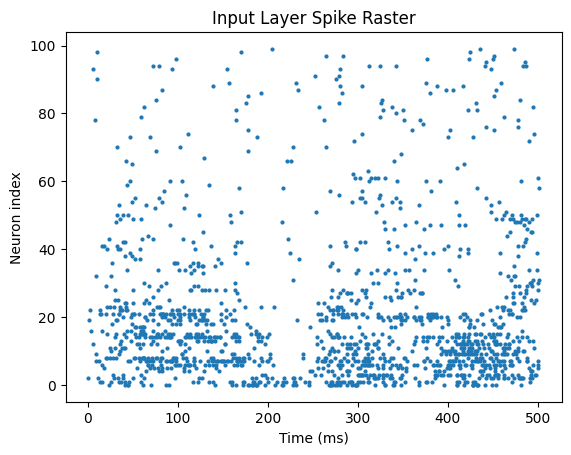

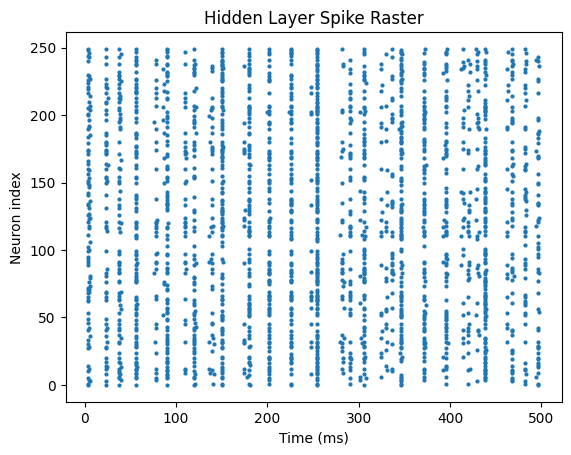

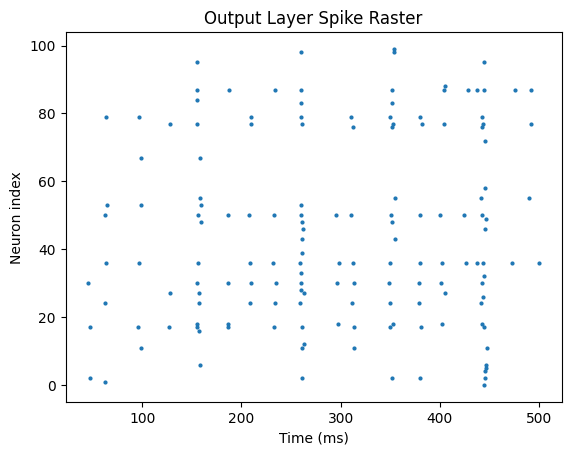

In [1]:
# =========================================================
# SACC – Conductance STDP (Input→Hidden→Output)
# =========================================================

!pip install brian2 torchmetrics librosa soundfile -q

import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from brian2 import *
from scipy.ndimage import gaussian_filter1d
from torchmetrics.audio import ScaleInvariantSignalNoiseRatio
import torch

# =========================================================
# 1. Load Audio
# =========================================================

clean, sr = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/clean_trainset_28spk_wav/p226_001.wav', sr=16000)
noisy, _  = librosa.load('/kaggle/input/datasets/muhmagdy/valentini-noisy/noisy_trainset_28spk_wav/p226_001.wav', sr=16000)

sr_new = 8000
clean = librosa.resample(clean, orig_sr=sr, target_sr=sr_new)
noisy = librosa.resample(noisy, orig_sr=sr, target_sr=sr_new)

segment_dur = 0.5
segment_len = int(sr_new * segment_dur)

clean = clean[:segment_len]
noisy = noisy[:segment_len]

# =========================================================
# 2. STFT → Rate Encoding
# =========================================================

num_inputs = 100
num_hidden = 250

def get_windowed_rates(audio, sr, window_ms=2, num_channels=100):
    n_fft = 256
    hop_length = int(sr * window_ms / 1000)
    D = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    mag = np.abs(D)

    rates_list = []
    for frame in mag.T:
        reshaped = frame[:num_channels * (len(frame)//num_channels)]
        rates = np.mean(reshaped.reshape(-1, num_channels), axis=0)
        rates = np.clip(rates * 400, 5, 300)
        rates_list.append(rates)

    return np.array(rates_list) * Hz, hop_length / sr

frame_rates, dt_frame = get_windowed_rates(noisy, sr_new, num_channels=num_inputs)
num_frames = len(frame_rates)

print("Mean input rate:", np.mean(frame_rates/Hz))

# =========================================================
# 3. Network Setup
# =========================================================

start_scope()
defaultclock.dt = 0.5*ms
t_step = dt_frame * second

taum = 20*ms
taue = 5*ms

Ee = 0*mV
El = -70*mV
Vr = -60*mV
Vt_base = -55*mV

tau_theta = 100*ms
eta_theta = 0.0005*volt
target_rate = 15*Hz

# ---------------------------------------------------------
# Neuron equations (conductance + adaptive threshold)
# ---------------------------------------------------------
Ei = -80*mV          # inhibitory reversal potential
taui = 10*ms         # inhibitory decay time constant

eqs_neurons = '''
dv/dt = (ge*(Ee - v) + gi*(Ei - v) + El - v)/taum : volt (unless refractory)

dge/dt = -ge/taue : 1
dgi/dt = -gi/taui : 1

dtheta/dt = -(theta - Vt_base)/tau_theta : volt
'''
# ---------------------------------------------------------
# Layers
# ---------------------------------------------------------

input_layer = PoissonGroup(num_inputs, rates=frame_rates[0])

hidden = NeuronGroup(num_hidden, eqs_neurons,
                     threshold='v > theta',
                     reset='v = Vr',
                     refractory=3*ms,
                     method='euler')

hidden.v = El
hidden.theta = Vt_base

output_layer = NeuronGroup(num_inputs, eqs_neurons,
                           threshold='v > theta',
                           reset='v = Vr',
                           refractory=4*ms,
                           method='euler')

output_layer.v = El
output_layer.theta = Vt_base

num_inh = int(num_hidden * 0.4)   # 40% inhibitory population
inh = NeuronGroup(num_inh, '''
dv/dt = (ge*(Ee - v) + gi*(Ei - v) + El - v)/taum : volt (unless refractory)

dge/dt = -ge/taue : 1
dgi/dt = -gi/taui : 1
'''
threshold='v > -50*mV',
reset='v = Vr',
refractory=4*ms,
method='euler')

inh.v = El

# =========================================================
# 4. STDP – Input → Hidden
# =========================================================

taupre = 20*ms
taupost = 20*ms
gmax = 1

dApre = 0.01
dApost = -dApre * taupre/taupost * 1.05

S_in_h = Synapses(input_layer, hidden,
                  '''
                  w : 1
                  dApre/dt = -Apre/taupre : 1 (event-driven)
                  dApost/dt = -Apost/taupost : 1 (event-driven)
                  ''',
                  on_pre='''
                  ge_post += w
                  Apre += dApre
                  w = clip(w + Apost, 0, gmax)
                  ''',
                  on_post='''
                  Apost += dApost
                  w = clip(w + Apre, 0, gmax)
                  ''')

S_in_h.connect(p=0.25)
S_in_h.w = '0.1 + 0.05*rand()'
# 🔹 Random biologically realistic delays (1–5 ms)
S_in_h.delay = '1*ms + 4*ms*rand()'

# =========================================================
# 5. STDP – Hidden → Output
# =========================================================

S_h_out = Synapses(hidden, output_layer,
                   '''
                   w : 1
                   dApre/dt = -Apre/taupre : 1 (event-driven)
                   dApost/dt = -Apost/taupost : 1 (event-driven)
                   ''',
                   on_pre='''
                   ge_post += w
                   Apre += dApre
                   w = clip(w + Apost, 0, gmax)
                   ''',
                   on_post='''
                   Apost += dApost
                   w = clip(w + Apre, 0, gmax)
                   ''')

S_h_out.connect(p=0.05)
S_h_out.w = '0.1 + 0.05*rand()'
# 🔹 Random delays (1–5 ms)
S_h_out.delay = '1*ms + 4*ms*rand()'
# Lateral inhibition in hidden
# =========================================================
# 5. STDP  -- Hidden -- Ihib ---> ex
# =========================================================
S_hidden_inhi = Synapses(input_layer, inh,
                '''
                w : 1
                ''',
                on_pre='ge_post += w')

S_hidden_inhi.connect(p=0.15)
S_hidden_inhi.w = '0.02 + 0.01*rand()'
S_hidden_inhi.delay = '1*ms + 3*ms*rand()'
# =========================================================
# 5. STDP – Inhi -- Hidden
# =========================================================
taupre_i = 20*ms
taupost_i = 20*ms
gmax_i = 0.1

eta_i = 0.005

S_ie = Synapses(inh, hidden,
                '''
                w : 1
                dApre/dt = -Apre/taupre_i : 1 (event-driven)
                dApost/dt = -Apost/taupost_i : 1 (event-driven)
                ''',
                on_pre='''
                gi_post += w
                Apre += 1.
                w = clip(w - eta_i*Apost, 0, gmax_i)
                ''',
                on_post='''
                Apost += 1.
                w = clip(w + eta_i*Apre, 0, gmax_i)
                ''')

S_ie.connect(p=0.05)
S_ie.w = '0.3 + 0.1*rand()'
S_ie.delay = '0.5*ms + 2*ms*rand()'

# =========================================================
# 6. Monitors
# =========================================================
M_input = SpikeMonitor(input_layer)
M_hidden = SpikeMonitor(hidden)
M_output = SpikeMonitor(output_layer)

hidden_rates_history = []
sparsity_values = []
active_counts = []

net = Network(collect())

print("Running simulation...")

# =========================================================
# 7. Simulation Loop + Homeostasis
# =========================================================

for f in range(num_frames):

    input_layer.rates = frame_rates[f]
    net.run(t_step)

    frame_start = f * t_step
    frame_end = frame_start + t_step

    spikes_hidden = (M_hidden.t >= frame_start) & (M_hidden.t < frame_end)
    spike_indices_hidden = M_hidden.i[spikes_hidden]

    active = len(np.unique(spike_indices_hidden))
    sparsity = active / num_hidden

    sparsity_values.append(sparsity)
    active_counts.append(active)

    pop_rate = len(spike_indices_hidden)/(num_hidden*(t_step/second))
    hidden_rates_history.append(pop_rate)

    # Adaptive threshold
    rate_error = (pop_rate*Hz - target_rate)/Hz
    hidden.theta += eta_theta * rate_error

print("Simulation completed")

# =========================================================
# 8. Reconstruction FROM OUTPUT LAYER
# =========================================================

spike_counts = np.zeros(num_frames)

for f in range(num_frames):
    frame_start = f * t_step
    frame_end = frame_start + t_step
    spikes = (M_output.t >= frame_start) & (M_output.t < frame_end)
    spike_counts[f] = np.sum(spikes)

decoded_env = gaussian_filter1d(spike_counts, sigma=1)
decoded_env = decoded_env / (np.max(decoded_env)+1e-8)

decoded_full = np.interp(np.arange(len(noisy)),
                         np.linspace(0,len(noisy)-1,num_frames),
                         decoded_env)

decoded_full *= np.std(clean)*0.6

# =========================================================
# 9. Metrics
# =========================================================

metric = ScaleInvariantSignalNoiseRatio()

clean_t = torch.tensor(clean, dtype=torch.float32)
recon_t = torch.tensor(decoded_full[:len(clean)], dtype=torch.float32)

si_snr = metric(recon_t, clean_t)

input_snr = 10*np.log10(np.var(clean)/(np.var(noisy-clean)+1e-8))
output_snr = 10*np.log10(np.var(clean)/(np.var(decoded_full[:len(clean)]-clean)+1e-8))

print("\n=============================")
print("RESULTS")
print("=============================")
print("SI-SNR:", si_snr.item())
print("Input SNR:", input_snr)
print("Output SNR:", output_snr)
print("SNR Improvement:", output_snr-input_snr)
print("Average sparsity:", np.mean(sparsity_values))
print("Average active neurons:", np.mean(active_counts))
print("===========================# =========================================================")
# 7B. Spike Raster Plots
# =========================================================

print("Plotting spike rasters...")

# -----------------------
# Input Layer
# -----------------------
plt.figure()
plt.scatter(M_input.t/ms, M_input.i, s=4)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Input Layer Spike Raster')
plt.show()

# -----------------------
# Hidden Layer
# -----------------------
plt.figure()
plt.scatter(M_hidden.t/ms, M_hidden.i, s=4)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Hidden Layer Spike Raster')
plt.show()

# -----------------------
# Output Layer
# -----------------------
plt.figure()
plt.scatter(M_output.t/ms, M_output.i, s=4)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Output Layer Spike Raster')
plt.show()
